# Run this to enable loading from relative packes

In [1]:
%load_ext autoreload
%autoreload 2
if "PKG" not in globals():
  import importlib, sys, pathlib # https://stackoverflow.com/a/50395128/11996983
  PKG = %pwd
  PKG = pathlib.Path(PKG)
  root_parent_level = 1
  root = PKG
  full_pkg = f"{root.name}"
  for _ in range(root_parent_level):
    root = root.parent
    full_pkg = f"{root.name}.{full_pkg}"
    MODULE_PATH = f"{root}{pathlib.os.path.sep}__init__.py"
    MODULE_NAME = f"{root.name}"
    spec = importlib.util.spec_from_file_location(MODULE_NAME, MODULE_PATH)
    module = importlib.util.module_from_spec(spec)
    sys.modules[spec.name] = module
    spec.loader.exec_module(module)
  __package__ = full_pkg


# Save plots with no embeded fonts

In [2]:
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# Common Imports

In [3]:
import platform
if "Ubuntu" in platform.version():
  import os
  os.environ["OnedriveConsumer"] = rf"{os.path.expanduser('~')}/OnedrivePersonal/"
  os.environ["OnedriveCommercial"] = rf"{os.path.expanduser('~')}/OnedriveFloating/"

In [4]:
import os
from pathlib import Path
from .common.definitions import BrainRegion

# The path where results are saved

In [5]:
# Papermill parameters -- code/run_notebooks.py overrides these.
# Everything is off by default, so running the notebook writes nothing.
SAVE_FIGS = False           # write figures under results/
SAVE_DATA = False           # rewrite cached intermediate data under data/
PAPER_FIGURES_ONLY = False  # skip per-subject / per-session figures

In [7]:
# Paths are relative to this notebook, which lives in code/ like every other
# notebook here. It was written for caiman/TwoP/again/, beside a pkl/ folder.
RESULTS_DIR = r"../results/2P"
fig_save_prefix = RESULTS_DIR

# Load data into a dataframe

In [8]:
from .twop.dataload import loadEpochTraces

# Raw fluorescence for the 23 M2/ALM L2/3 sessions, cut down to the 30 columns
# this notebook reads (docs/execution-plan.md, D1). Running cells 12-50 on it
# gives the same accepted neurons and dF/F traces as on the full 33-session file.
df_all_by_epoch = loadEpochTraces()

# Active neurons extraction: Restrict analysis to neurons that are active during the states we care about

In [9]:
from .twop.alignsampling import alignSampling
from .pipeline import tracesnormalize
import pandas as pd

TIME_BEFORE_SAMPLING = 0.1
TIME_AFTER_MOVEMENT = 0.1

# Don't use df_all_by_epoch_df_f, use the unormalized df_all_by_epoch for now
_alignSamplingKargs = dict(normalization=tracesnormalize.NormalizeZScore(set_name="neuronal"),
                           time_before_sampling=TIME_BEFORE_SAMPLING,
                           time_after_sampling=TIME_AFTER_MOVEMENT,)

unnormed_sampling_df = alignSampling(df=df_all_by_epoch.copy(), **_alignSamplingKargs,
                                     normalize_epoch_time=False,)
unnormed_sampling_df["epoch"] = "Sampling"
normed_sampling_df = alignSampling(df_all_by_epoch.copy(), **_alignSamplingKargs,
                                   normalize_epoch_time=True,)
normed_sampling_df["epoch"] = "Sampling"


# Figure 6B normalises feedback responses by each neuron's sampling mean and
# std -- the two numbers NormalizeZScore used above and this repo's pipeline
# does not keep (the author's later caiman pipeline stores them in a
# neuronal_stats column). Same call without normalising gives exactly the
# traces it consumed; twop.zscorestats recomputes the statistics from them.
from .pipeline.tracesnormalize import NoNormalization
from .twop.zscorestats import sessionTraceStats

_rawSamplingKargs = dict(_alignSamplingKargs, normalization=NoNormalization())
raw_sampling_df = alignSampling(df=df_all_by_epoch.copy(), **_rawSamplingKargs,
                                normalize_epoch_time=False)
sampling_stats_df = sessionTraceStats(raw_sampling_df)


Removing decision time trials and nan-time trials...


Decision time filter: 21,880/22,483 (603 rows (not trials) removed)
Done...
Processing: Split data by trial ['Name', 'Date', 'SessionNum']
Processing: Applying on full trace


  0%|          | 0/23 [00:00<?, ?it/s]

Processing: Applying no normalization to trace
Processing: Applying no normalization to trace
Processing: Applying no normalization to trace
Processing: Applying no normalization to trace
Processing: Applying no normalization to trace
Processing: Applying no normalization to trace
Processing: Applying no normalization to trace
Processing: Applying no normalization to trace
Processing: Applying no normalization to trace
Processing: Applying no normalization to trace
Processing: Applying no normalization to trace
Processing: Applying no normalization to trace
Processing: Applying no normalization to trace
Processing: Applying no normalization to trace
Processing: Applying no normalization to trace
Processing: Applying no normalization to trace
Processing: Applying no normalization to trace
Processing: Applying no normalization to trace
Processing: Applying no normalization to trace
Processing: Applying no normalization to trace
Processing: Applying no normalization to trace
Processing: A

Processing: Aligning traces to 0.1 sec(s) before epoch(s): ['Sampling']  and 0 sec(s) afterwards


...

Processing: Split data by trial ['Name', 'Date', 'SessionNum']
Processing: Split data by trial ['TrialNumber']


  0%|          | 0/23 [00:00<?, ?it/s]

Processing: Concatenated epochs of the same trial-number together


  0%|          | 0/5351 [00:00<?, ?it/s]

Processing: Collapsing the dataframes back into one dataframe


In [10]:
[col for col in df_all_by_epoch.columns if any([col_name in col for col_name in ["dur", "time"]])]
df_all_by_epoch.sort_values(["Date", "ShortName", "TrialNumber", "state_id", "trace_start_idx"])[["ShortName", "TrialNumber", "state_id", "epoch", "epoch_time"]]

,ShortName,TrialNumber,state_id,epoch,epoch_time
6046,GP4_28_S1_L41_D250_M2L,60,1,Wait Trial Start,4.393702
6047,GP4_28_S1_L41_D250_M2L,60,8,Sampling,0.832141
6048,GP4_28_S1_L41_D250_M2L,60,13,Movement to Lateral Port,0.632427
6049,GP4_28_S1_L41_D250_M2L,60,19,Reward,2.562993
6050,GP4_28_S1_L41_D250_M2L,61,1,Wait Trial Start,0.332856
...,...,...,...,...,...
22478,GP4_85_s10_L70_D250_ALM,321,19,Reward,1.764138
22479,GP4_85_s10_L70_D250_ALM,322,1,Wait Trial Start,0.332856
22480,GP4_85_s10_L70_D250_ALM,322,8,Sampling,1.098426
22481,GP4_85_s10_L70_D250_ALM,322,13,Movement to Lateral Port,0.366142


In [11]:
from .twop.evd_conditions_common import _alignAroundEpoch
from .pipeline import pipeline
from .pipeline import traceswidth, tracesrestructure, tracesnormalize

def makeNormedAll(df):
    df = df.reset_index(drop=True)
    df = df[df.Layer == "L23"]
    df = df[df.BrainRegion.isin([BrainRegion.M2_Bi, BrainRegion.ALM_Bi])]
    print("Extracting Reward and Punishment epochs")

    # chain = pipeline.Chain(
    #     pipeline.By("ShortName"),
    #         tracesnormalize.NormalizeZScore(set_name="neuronal"),
    #     pipeline.RecombineResults(),
    # )
    # df = chain.run(df)


    TIME_AFTER_FEEDBACK = 0.3
    TIME_AFTER_FEEDBACK_START = 0#int(round(0.2 * df.acq_sampling_rate.iloc[0]))
    df_around_reward = _alignAroundEpoch(df=df.copy(),
                                    align_to_epoch="Reward",
                                    time_before=0, time_after=TIME_AFTER_FEEDBACK,
                                    limit_trial_end=False, normalization=None)
    df_around_punishment = _alignAroundEpoch(df=df.copy(),
                                    align_to_epoch="Punishment",
                                    time_before=0, time_after=TIME_AFTER_FEEDBACK,
                                    limit_trial_end=False, normalization=None)
    print(f"Time after feedback start: {TIME_AFTER_FEEDBACK_START} frames")
    df_around_reward["trace_start_idx"] = df_around_reward.trace_start_idx + TIME_AFTER_FEEDBACK_START
    df_around_punishment["trace_start_idx"] = df_around_punishment.trace_start_idx + TIME_AFTER_FEEDBACK_START

    # We don't actually have to, but to speed up the processing we removing the
    # feedback epochs as we have already obtained them
    df = df[df.ChoiceCorrect.notnull()]
    df_wo_feedback = df[~df.epoch.isin(["Reward", "Punishment"])]
    print(f"Full: {len(df):,} - Len df_wo_feedback: {len(df_wo_feedback):,} ")
    chain = pipeline.Chain(
        pipeline.By("ShortName"), pipeline.By("epoch"),
           traceswidth.NormalizeTime(show_progress=False),
        pipeline.RecombineResults(),
    )
    df_wo_feedback_norm = chain.run(df_wo_feedback)

    df_concat = pd.concat([df_wo_feedback_norm, df_around_reward, df_around_punishment],
                           ignore_index=True)
    df_concat = df_concat.sort_values(["BrainRegion", "Date", "ShortName", "TrialNumber", "state_id"])
    df_concat = df_concat[df_concat.ChoiceCorrect.notnull()]
    df_concat = df_concat.reset_index(drop=True)
    return df_concat

normed_all_df = makeNormedAll(df_all_by_epoch.copy())


Extracting Reward and Punishment epochs
Processing: Aligning traces to 0 sec(s) before epoch(s): ['Reward']  and 0.3 sec(s) afterwards


Processing: Collapsing the dataframes back into one dataframe
Processing: Aligning traces to 0 sec(s) before epoch(s): ['Punishment']  and 0.3 sec(s) afterwards


Processing: Collapsing the dataframes back into one dataframe
Time after feedback start: 0 frames
Full: 22,165 - Len df_wo_feedback: 16,793 
Processing: Split data by trial ['ShortName']
Processing: Split data by trial ['epoch']


  0%|          | 0/23 [00:00<?, ?it/s]

Processing: Normalize traces time to have a common median length


  0%|          | 0/88 [00:00<?, ?it/s]

Processing: Collapsing the dataframes back into one dataframe


In [12]:
normed_all_df[["ShortName", "TrialNumber", "state_id", "epoch", "epoch_time"]]

,ShortName,TrialNumber,state_id,epoch,epoch_time
0,gp4_81_S5_L50_D250_ALM,7,1,Wait Trial Start,0.299571
1,gp4_81_S5_L50_D250_ALM,7,8,Sampling,1.065140
2,gp4_81_S5_L50_D250_ALM,7,13,Movement to Lateral Port,0.332856
3,gp4_81_S5_L50_D250_ALM,7,19,Reward,1.697567
4,gp4_81_S5_L50_D250_ALM,8,1,Wait Trial Start,0.299571
...,...,...,...,...,...
22160,GP4_23_s3_L50_D250_M2,318,19,Reward,2.962421
22161,GP4_23_s3_L50_D250_M2,319,1,Wait Trial Start,0.399427
22162,GP4_23_s3_L50_D250_M2,319,8,Sampling,0.532570
22163,GP4_23_s3_L50_D250_M2,319,13,Movement to Lateral Port,0.399427


In [13]:
def expandDFs(df):
    df_dict_li = {"BrainRegion": [],
              "ShortName": [],
              "TrialNumber": [],
              "epoch": [],
              "trace_id": [],
              "trace": [],
              "ChoiceCorrect": [],
              "ChoiceLeft": [],
              "acq_sampling_rate": []}
    for br, br_df in df.groupby("BrainRegion"):
        br_str = str(BrainRegion(br)).split("_")[0]
        for sess, sess_df in br_df.groupby("ShortName"):
            for trial, trial_df in sess_df.groupby("TrialNumber"):
                trial_outcome = trial_df.ChoiceCorrect.iloc[0]
                trial_choice_left = trial_df.ChoiceLeft.iloc[0]
                for epoch, epoch_df in trial_df.groupby("epoch"):
                    assert len(epoch_df) == 1, display(epoch_df) or f"More than one epoch {epoch} in trial {trial} of session {sess}"
                    neurons = epoch_df.traces_sets.iloc[0]["neuronal"]
                    start_idx = epoch_df.trace_start_idx.iloc[0]
                    end_idx = epoch_df.trace_end_idx.iloc[0]
                    acq_sampling_rate = epoch_df.acq_sampling_rate.iloc[0]
                    for trace_id, trace in neurons.items():
                        trace = trace[start_idx:end_idx+1]
                        df_dict_li["BrainRegion"].append(br_str)
                        df_dict_li["ShortName"].append(sess)
                        df_dict_li["TrialNumber"].append(trial)
                        df_dict_li["epoch"].append(epoch)
                        df_dict_li["trace_id"].append(trace_id)
                        df_dict_li["trace"].append(trace)
                        df_dict_li["ChoiceCorrect"].append(trial_outcome)
                        df_dict_li["ChoiceLeft"].append(trial_choice_left)
                        df_dict_li["acq_sampling_rate"].append(acq_sampling_rate)
    print("Creating DF")
    df = pd.DataFrame(df_dict_li)
    df["long_trace_id"] = df["ShortName"] + "_" + df["trace_id"].astype(str)
    return df

expanded_df = expandDFs(normed_all_df.copy())
expanded_df

Creating DF


,BrainRegion,ShortName,TrialNumber,epoch,trace_id,trace,ChoiceCorrect,ChoiceLeft,acq_sampling_rate,long_trace_id
0,ALM,GP4_23_s6_L50_D250_ALM,167,Movement to Lateral Port,0,"[879.21106, 732.61316, 539.418, 899.4368, 726....",0.0,1.0,30.043,GP4_23_s6_L50_D250_ALM_0
1,ALM,GP4_23_s6_L50_D250_ALM,167,Movement to Lateral Port,1,"[1734.899, 1243.8436, 1355.4657, 1122.8319, 13...",0.0,1.0,30.043,GP4_23_s6_L50_D250_ALM_1
2,ALM,GP4_23_s6_L50_D250_ALM,167,Movement to Lateral Port,2,"[1229.0048, 976.8823, 718.9087, 745.7356, 1090...",0.0,1.0,30.043,GP4_23_s6_L50_D250_ALM_2
3,ALM,GP4_23_s6_L50_D250_ALM,167,Movement to Lateral Port,3,"[443.99982, 682.149, 573.7477, 622.7868, 621.6...",0.0,1.0,30.043,GP4_23_s6_L50_D250_ALM_3
4,ALM,GP4_23_s6_L50_D250_ALM,167,Movement to Lateral Port,4,"[4174.4585, 4312.4517, 4066.493, 4020.6528, 38...",0.0,1.0,30.043,GP4_23_s6_L50_D250_ALM_4
...,...,...,...,...,...,...,...,...,...,...
3850455,M2,GP4_85_s3_L70_D250_mm2,308,Wait Trial Start,323,"[535.7826, 306.992, 341.42688, 363.67316, 360....",1.0,1.0,30.043,GP4_85_s3_L70_D250_mm2_323
3850456,M2,GP4_85_s3_L70_D250_mm2,308,Wait Trial Start,379,"[442.72882, 91.44006, 208.31787, 515.0346, 409...",1.0,1.0,30.043,GP4_85_s3_L70_D250_mm2_379
3850457,M2,GP4_85_s3_L70_D250_mm2,308,Wait Trial Start,391,"[527.265, 619.44385, 565.26807, 850.3795, 720....",1.0,1.0,30.043,GP4_85_s3_L70_D250_mm2_391
3850458,M2,GP4_85_s3_L70_D250_mm2,308,Wait Trial Start,439,"[581.65674, 787.2894, 577.9026, 912.97144, 757...",1.0,1.0,30.043,GP4_85_s3_L70_D250_mm2_439


In [14]:
def averageTracesAcrossEpoch(df):
    rows_li = []
    for (trace_id, epoch), trace_df in df.groupby(["long_trace_id", "epoch"]):
        ex_row = trace_df.iloc[0].copy()
        average_trace = trace_df.trace.mean(axis=0)
        ex_row["trace"] = average_trace
        ex_row["TrialNumber"] = f"Avg_{epoch}"
        rows_li.append(ex_row)
    df = pd.DataFrame(rows_li)
    return df

expanded_avg_df = averageTracesAcrossEpoch(expanded_df.copy())
expanded_avg_df

,BrainRegion,ShortName,TrialNumber,epoch,trace_id,trace,ChoiceCorrect,ChoiceLeft,acq_sampling_rate,long_trace_id
1700087,M2,GP4_23_S1_L50_D250_mm2,Avg_Decision Time,Decision Time,0,"[425.059814453125, 455.801953125, 381.47788085...",0.0,0.0,30.043,GP4_23_S1_L50_D250_mm2_0
1539707,M2,GP4_23_S1_L50_D250_mm2,Avg_Movement to Lateral Port,Movement to Lateral Port,0,"[396.6060108985765, 403.62030137900354, 401.79...",1.0,1.0,30.043,GP4_23_S1_L50_D250_mm2_0
1546142,M2,GP4_23_S1_L50_D250_mm2,Avg_Punishment,Punishment,0,"[445.15894214527026, 506.5072318412162, 469.92...",0.0,0.0,30.043,GP4_23_S1_L50_D250_mm2_0
1540202,M2,GP4_23_S1_L50_D250_mm2,Avg_Reward,Reward,0,"[513.7242980072464, 489.6288496376812, 494.404...",1.0,1.0,30.043,GP4_23_S1_L50_D250_mm2_0
1540697,M2,GP4_23_S1_L50_D250_mm2,Avg_Sampling,Sampling,0,"[413.63770573843414, 386.61752112989325, 389.1...",1.0,1.0,30.043,GP4_23_S1_L50_D250_mm2_0
...,...,...,...,...,...,...,...,...,...,...
1418741,ALM,gp4_81_S8_L65_D250_ALM,Avg_Movement to Lateral Port,Movement to Lateral Port,97,"[429.0537037037037, 408.92060185185187, 419.97...",1.0,1.0,30.043,gp4_81_S8_L65_D250_ALM_97
1423781,ALM,gp4_81_S8_L65_D250_ALM,Avg_Punishment,Punishment,97,"[390.9327083333333, 396.3877083333333, 421.010...",0.0,0.0,30.043,gp4_81_S8_L65_D250_ALM_97
1418831,ALM,gp4_81_S8_L65_D250_ALM,Avg_Reward,Reward,97,"[443.810577552356, 457.22819862565444, 431.304...",1.0,1.0,30.043,gp4_81_S8_L65_D250_ALM_97
1418921,ALM,gp4_81_S8_L65_D250_ALM,Avg_Sampling,Sampling,97,"[425.76171875, 434.89913194444443, 442.3855902...",1.0,1.0,30.043,gp4_81_S8_L65_D250_ALM_97


In [15]:
examples_ids = {
        "GP4_23_s6_L50_D250_ALM_133",
        "GP4_28_S2_L51_D250_M2L_216",
        "GP4_28_S4_L40_D250_M2L_74",
        "GP4_28_S5_L40_D250_M2L_95",
        "GP4_85_s3_L70_D250_mm2_95",
        "GP4_23_S1_L50_D250_mm2_322",
        "GP4_23_s6_L50_D250_ALM_217",
        "gp4_81_S5_L50_D250_ALM_35",
        "GP4_28_S1_L41_D250_M2L_45",
        "GP4_23_S1_L50_D250_mm2_217",
        "GP4_85_s3_L70_D250_mm2_27",
        "GP4_28_S1_L41_D250_M2L_62",
        "GP4_28_S2_L51_D250_M2L_354",
        "GP4_28_S2_L51_D250_M2L_39",
        "GP4_28_S2_L51_D250_M2L_141",
        "GP4_28_S2_L51_D250_M2L_20",
        "GP4_28_S1_L41_D250_M2L_95",
        # "GP4_23_s11_L70_D500_alm_14",
        "gp4_81_S5_L50_D250_ALM_12",
        "GP4_23_s6_L50_D250_ALM_148",
        "GP4_23_s6_L50_D250_ALM_151", # More M2 than ALM
        "gp4_81_S5_L50_D250_ALM_35",
        "GP4_23_s7_L50_D250_ALM_221",
    }

In [16]:
# Coped from ROC_tests_new15_09: # Sequence characterization
# The ten functions that used to live here are shared with 2pAnalysis and
# tested in twop/tracereliability.py.
from .twop.tracereliability import (DecideNeurons, StdDistCollector,
                                    loopSessionsExampleNeurons)
import numpy as np

np.seterr(all='raise')

_decide_neurons = DecideNeurons(smooth_sigma=1)

_normed_collector = StdDistCollector(_decide_neurons)
loopSessionsExampleNeurons(normed_sampling_df, random_fraction=1, seed=1,
                           pdf_str="max_firing_all_normed",
                           processFn=_normed_collector.track,
                           save_figs=SAVE_FIGS and not PAPER_FIGURES_ONLY, fig_save_prefix=fig_save_prefix)
all_res_normed_dict = _normed_collector.res_dict
all_res_normed_df = _normed_collector.frame()

_unnormed_collector = StdDistCollector(_decide_neurons)
loopSessionsExampleNeurons(unnormed_sampling_df, random_fraction=1, seed=1,
                           pdf_str="max_firing_all_unnormed",
                           processFn=_unnormed_collector.track,
                           save_figs=SAVE_FIGS and not PAPER_FIGURES_ONLY, fig_save_prefix=fig_save_prefix)
all_res_unnormed_dict = _unnormed_collector.res_dict
all_res_unnormed_df = _unnormed_collector.frame()

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]

## Plot Heatmaps in feedback

In [17]:
from .pipeline.utils import filterNanGaussianConserving
from .common.clr import colorMapParula
from scipy.stats import sem
from .common.clr import BrainRegion as BRClr

def plotSessHeatmap(df, sigma, sampling_accept_threshold, extra_offset,
                    plot, save_figs=False):
    EPOCHS_ORDER = ["Wait Trial Start", "Sampling", "Movement to Lateral Port",
                    "Reward", "Punishment"
                    ]
    df = df[df.epoch.isin(EPOCHS_ORDER)]
    df = df.sort_values("epoch", key=lambda x: x.map({e: i for i, e in enumerate(EPOCHS_ORDER)}))

    br_accept_li = []
    for br, br_df in df.groupby("BrainRegion"):
        for sess, sess_df in br_df.groupby("ShortName"):
            sampling_start_idx = sess_df[sess_df.epoch == "Wait Trial Start"].trace.iloc[0].shape[0]
            movement_start_idx =  sampling_start_idx + \
                                sess_df[sess_df.epoch == "Sampling"].trace.iloc[0].shape[0]
            reward_start_idx = movement_start_idx + \
                            sess_df[sess_df.epoch == "Movement to Lateral Port"].trace.iloc[0].shape[0]
            punishment_start_idx = reward_start_idx + \
                                sess_df[sess_df.epoch == "Reward"].trace.iloc[0].shape[0]

            if plot:
                fig, ax = plt.subplots(1, 1)
                fig.set_size_inches(12, 12)
            concat_traces_li = []
            is_valid_trace_li = []
            max_sampling_idxs_li = []
            for trace_id, trace_avg_epochs_df in sess_df.groupby("trace_id"):
                def getEpochTrace(epoch_name):
                    trace = trace_avg_epochs_df[trace_avg_epochs_df.epoch == epoch_name].trace
                    assert len(trace) == 1, display(trace) or f"More than one trace for epoch {epoch_name} in session {sess}"
                    trace = trace.values[0]
                    return trace
                wait_sart_trace = getEpochTrace("Wait Trial Start")
                sampling_trace = getEpochTrace("Sampling")
                movement_trace = getEpochTrace("Movement to Lateral Port")
                reward_trace = getEpochTrace("Reward")
                punishment_trace = getEpochTrace("Punishment")
                SPLIT_FEEDBACK = True
                if SPLIT_FEEDBACK:
                    concat_wo_feedback = np.concatenate(
                             [wait_sart_trace, sampling_trace, movement_trace,])
                    concat_wo_feedback = filterNanGaussianConserving(concat_wo_feedback, sigma=sigma,
                                                                     axis=0)
                    reward_smoothed = filterNanGaussianConserving(reward_trace, sigma=sigma, axis=0)
                    punishment_smoothed = filterNanGaussianConserving(punishment_trace, sigma=sigma, axis=0)
                    concat_trace = np.concatenate([concat_wo_feedback, reward_smoothed,
                                                   punishment_smoothed])
                    max_sampling_idx = np.argmax(concat_wo_feedback[
                              sampling_start_idx-extra_offset:reward_start_idx-extra_offset])
                    max_sampling_idx += sampling_start_idx - extra_offset
                    max_sampling_val = concat_wo_feedback[max_sampling_idx]
                    # THRESHOLD_RATE = 1
                    threshold_val = max_sampling_val * sampling_accept_threshold
                    is_valid_trace = any(reward_smoothed > threshold_val) or \
                                     any(punishment_smoothed > threshold_val)
                    is_valid_trace_li.append(is_valid_trace)
                    max_sampling_idxs_li.append(max_sampling_idx)
                else:
                    concat_all_wo_punish = np.concatenate(
                        [wait_sart_trace, sampling_trace, movement_trace, reward_trace])
                    concat_all_wo_punish = filterNanGaussianConserving(concat_all_wo_punish, sigma=sigma,
                                                                        axis=0)
                    concat_mov_punish = np.concatenate([movement_trace, punishment_trace])
                    concat_mov_punish = filterNanGaussianConserving(concat_mov_punish, sigma=sigma,
                                                                    axis=0)
                    # Now tale out movement
                    concat_punish = concat_mov_punish[-len(punishment_trace):]
                    concat_trace = np.concatenate([concat_all_wo_punish, concat_punish
                    ])
                # Normalize between 0 and 1
                concat_trace = (concat_trace - concat_trace.min()) / (
                                concat_trace.max() - concat_trace.min())
                concat_traces_li.append(concat_trace)

            concat_traces = np.array(concat_traces_li)
            is_valid_trace_li = np.array(is_valid_trace_li)
            max_sampling_idxs_li = np.array(max_sampling_idxs_li)
            # is_valid_trace_li = np.ones(concat_traces.shape[0], dtype=bool)

            total_traces_count = len(is_valid_trace_li)
            accepted_traces_count = np.sum(is_valid_trace_li)
            percent_accept = np.sum(is_valid_trace_li)/len(is_valid_trace_li)*100
            # print(f"Number of valid traces: {accepted_traces_count} / {total_traces_count} "
            #       f"({percent_accept:.2f}%)")
            br_accept_li.append({"total": total_traces_count,
                                 "accepted": accepted_traces_count,
                                 "percent": percent_accept,
                                 "ShortName": sess,
                                 "BreainRegion": br,})
            if not plot:
                continue
            # Sort by max value position during sampling epoch
            sort_idx = np.argsort(np.argmax(concat_traces[:,sampling_start_idx:movement_start_idx],
                                            axis=1))
            concat_traces = concat_traces[sort_idx, :]
            is_valid_trace_li = is_valid_trace_li[sort_idx]
            max_sampling_idxs_li = max_sampling_idxs_li[sort_idx]

            cmap = colorMapParula() # viridis
            ax.set_xlim(0, concat_traces.shape[1])
            imshow_kwargs = dict(extent=(0, concat_traces.shape[1],
                                         0, concat_traces.shape[0]),
                                 interpolation="none")
            concat_traces_accepted = concat_traces.copy()
            concat_traces_accepted[~is_valid_trace_li, :] = np.nan
            im = ax.imshow(concat_traces_accepted, cmap=cmap, **imshow_kwargs,)
            concat_traces_rejected = concat_traces.copy()
            concat_traces_rejected[is_valid_trace_li, :] = np.nan
            ax.imshow(concat_traces_rejected,
                      cmap="gray", **imshow_kwargs)
            for y_idx, max_sampling_idx in enumerate(max_sampling_idxs_li[::-1]):
                ax.plot([max_sampling_idx, max_sampling_idx],
                        [y_idx, y_idx + 1], color='r')

            ax.axvline(sampling_start_idx, color='k', ls="--", label="Sampling start")
            ax.axvline(movement_start_idx, color='k', ls="--", label="Movement start")
            ax.axvline(reward_start_idx, color='k', ls="--", label="Reward start")
            ax.axvline(punishment_start_idx, color='k', ls="--", label="Punishment start")
            # ax.legend()
            ax.set_title(f"{sess_df.BrainRegion.iloc[0]} - {sess_df.ShortName.iloc[0]}")
            ax.set_xlabel("Epochs")
            ax.set_ylabel("Neurons")
            ax.set_xticks([0, sampling_start_idx, movement_start_idx,
                        reward_start_idx, punishment_start_idx,])
            ax.set_xticklabels(["Start", "Sampling", "Movement",
                                "Reward", "Punishment"], rotation=45, ha='right')
            ax.set_yticks([])
            ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
            # ax.set_yticklabels(np.arange(0, concat_traces.shape[0], 10))
            fig.colorbar(im, ax=ax, label="Normalized Activity")
            if save_figs:
                fig.savefig(rf"{RESULTS_DIR}/heatmaps/sep_sess_masked/{br}_{sess_df.ShortName.iloc[0]}.svg",
                            bbox_inches='tight', dpi=300)
            plt.show()

    return pd.DataFrame(br_accept_li)


def loopThresholds(extra_offset, save_figs):
    accepted_sampling_traces = all_res_unnormed_df.loc[all_res_unnormed_df.prcnt_valid > 5, "trace_id"]
    res_df_li = []
    sampling_threshs_li = []
    for threshold in range(40, 150, 10):
        print(f"Threshold: {threshold}")
        res_df = plotSessHeatmap(#expanded_avg_df,
                                 expanded_avg_df[expanded_avg_df.long_trace_id.isin(accepted_sampling_traces)],
                                 sigma=2, sampling_accept_threshold=threshold/100, extra_offset=3,
                                 plot=False, save_figs=False)
        res_df["sampling_accept_threshold"] = threshold
        sampling_threshs_li.append(threshold)
        res_df_li.append(res_df)
    all_res_df = pd.concat(res_df_li, ignore_index=True)
    fig, ax = plt.subplots()
    fig.set_size_inches(10, 5)
    offset = -.5
    sampling_threshs_li = np.array(sampling_threshs_li)
    for br, br_df in all_res_df.groupby("BreainRegion"):
        mean = br_df.groupby("sampling_accept_threshold").percent.mean()
        sem_ = br_df.groupby("sampling_accept_threshold").percent.sem()
        ax.errorbar(sampling_threshs_li + offset,
                    mean, yerr=sem_, color=BRClr[br],
                    marker='o', capsize=5, elinewidth=2, markersize=5)
        for threshold_val in sampling_threshs_li:
            pts = br_df[br_df.sampling_accept_threshold == threshold_val].percent
            ax.scatter([threshold_val + offset]*len(pts), pts,
                        color=BRClr[br], s=10, alpha=0.5)
        offset += 1
    ax.set_xlabel("Feedback threshold as function of maximum sampling value")
    ax.set_ylabel("Accepted Traces (%)")
    ax.set_title("Accepted Traces in Feedback given Sampling max value")
    ax.set_xticks(sampling_threshs_li)
    ax.spines[["top", "right"]].set_visible(False)
    if save_figs:
        fig.savefig(rf"{RESULTS_DIR}/heatmaps/accepted_traces_thresholds.svg",
                    bbox_inches='tight', dpi=300)
    plt.show()


def plotOnce(threshold, extra_offset, save_figs):
    accepted_sampling_traces = all_res_unnormed_df.loc[all_res_unnormed_df.prcnt_valid > 5, "trace_id"]
    res_df = plotSessHeatmap(#expanded_avg_df,
                             expanded_avg_df[expanded_avg_df.long_trace_id.isin(accepted_sampling_traces)],
                             sigma=2, sampling_accept_threshold=threshold, extra_offset=extra_offset,
                             plot=True, save_figs=save_figs)
    fig, ax = plt.subplots()
    fig.set_size_inches(8, 8)
    idx = 0
    x_labels = []
    for br, br_df in list(res_df.groupby("BreainRegion"))[::-1]:
        # ax.bar(idx, br_df.percent.mean(), yerr=br_df.percent.sem(),
        #        label=br, edgecolor=BRClr[br], facecolor='none',
        #        width=.5)
        # ax.scatter([idx]*len(br_df), br_df.percent,
        #            color=BRClr[br], s=10, alpha=0.5)
        box = ax.boxplot(br_df.percent, positions=[idx], widths=0.5,
                         patch_artist=True, showfliers=True,
                         boxprops=dict(facecolor=BRClr[br], color=BRClr[br]),
                         medianprops=dict(color='k'),
                         whiskerprops=dict(color=BRClr[br]),
                         capprops=dict(color=BRClr[br]),
                         flierprops=dict(markerfacecolor=BRClr[br], marker='o', markersize=5))
        idx += 1
        x_labels.append(br)

    ax.set_xticks(np.arange(len(x_labels)))
    ax.set_xticklabels(x_labels)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlim(-.5, 2)
    ax.set_ylim(0, 80)
    ax.set_ylabel("Accepted Traces (%)")
    # Set y-axis to percentage
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
    ax.set_title(f"Accepted Traces in Feedback given Sampling max value\n"
                 f"Threshold: {threshold*100:.0f}%")
    if save_figs:
        fig.savefig(rf"{RESULTS_DIR}/heatmaps/accepted_traces_{threshold*100:.0f}.svg",
                    bbox_inches='tight', dpi=300)
    plt.show()


plotOnce(threshold=1, extra_offset=3, save_figs=False)
loopThresholds(extra_offset=3, save_figs=False)


Threshold: 40


Threshold: 50


Threshold: 60


Threshold: 70


Threshold: 80


...

Threshold: 100


Threshold: 110


Threshold: 120


Threshold: 130


Threshold: 140


In [18]:
# The feedback traces start on a decay, so it is flattened before the
# spread is measured -- see disable_first_neg_deflect in tracereliability.
_feedback_collector = StdDistCollector(_decide_neurons,
                                       disable_first_neg_deflect=True)
normed_feedback_df = normed_all_df[normed_all_df.epoch.isin(["Reward", "Punishment"])].copy()
loopSessionsExampleNeurons(normed_feedback_df, random_fraction=1, seed=1,
                           pdf_str="max_firing_all_unnormed",
                           processFn=_feedback_collector.track,
                           save_figs=SAVE_FIGS and not PAPER_FIGURES_ONLY, fig_save_prefix=fig_save_prefix)
all_res_cut_feedback_dict = _feedback_collector.res_dict
all_res_cut_feedback_df = _feedback_collector.frame()

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/13 [00:00<?, ?it/s]

In [19]:
from .twop.dataload import dataPath
from .util.portablepickle import savePortable

SAVE_CUT_FFEDBACK = False
if SAVE_CUT_FFEDBACK:
    _accepted_sampling_traces = all_res_unnormed_df.loc[all_res_unnormed_df.prcnt_valid > 5, "trace_id"]
    save_df = all_res_cut_feedback_df[all_res_cut_feedback_df.trace_id.isin(_accepted_sampling_traces)]
    _FP = dataPath("traces_cut_feedback_df.pkl")
    savePortable(save_df, _FP)
    print(f"Saved cut feedback df to {_FP}")

if False:
    # _FP = 
    # normed_feedback_df = normed_all_df[normed_all_df.epoch.isin(["Reward", "Punishment"])].copy()
    def keepPnlyAcceptedTraces(df, accepted_df):
        res_rows = []
        accepted_traces_by_sess = {}
        for sess, sess_df in accepted_df.groupby("ShortName"):
            accepted_traces = sess_df.trace_id.str.rsplit("_", n=1).str[1].values
            accepted_traces = accepted_traces.astype(int)
            accepted_traces_by_sess[sess] = set(accepted_traces)
        for row_idx, row in df.iterrows():
            new_traces_set = {}
            accepted_ids = accepted_traces_by_sess[row.ShortName]
            for set_name, traces_dict in row.traces_sets.items():
                new_traces_set[set_name] = {
                    trace_id: trace for trace_id, trace in traces_dict.items()
                    if trace_id in accepted_ids}
            row = row.copy()
            row["traces_sets"] = new_traces_set
            res_rows.append(row)
        return pd.DataFrame(res_rows)
                
    accepted_sampling_df = all_res_unnormed_df.loc[all_res_unnormed_df.prcnt_valid > 5]
    normed_feedback_filtered_df = keepPnlyAcceptedTraces(normed_feedback_df, accepted_sampling_df)
    savePortable(normed_feedback_filtered_df, dataPath("traces_cut_feedback_filtered_full_df.pkl"))

    normed_all_filtered_df = keepPnlyAcceptedTraces(normed_all_df, accepted_sampling_df)
    savePortable(normed_all_filtered_df, dataPath("traces_cut_normed_all_filtered_full_df.pkl"))
# normed_feedback_filtered_df[normed_feedback_filtered_df.ShortName == "GP4_23_s6_L50_D250_ALM"].traces_sets.iloc[0]
# all_res_unnormed_df[all_res_unnormed_df.prcnt_valid < 5].trace_id

## Feedvack percentage

In [20]:
import matplotlib.pyplot as plt
from .common.clr import BrainRegion as BRClr
from .pipeline.utils import filterNanGaussianConserving

def plotFeedbackExamples(df, df_ref, df_stats):
    # print("Example ids:", list(examples_ids)[0])
    _PRCNT_VALID = 5
    # for br, br_df in df.groupby("BrainRegion"):
    #     prcnt_valid = (br_df.prcnt_valid > _PRCNT_VALID).mean() * 100
    #     br_str = str(BrainRegion(br)).split("_")[0]
    #     print(f"{br_str} - @_PRCNT_VALID >=: {_PRCNT_VALID} = {prcnt_valid:.3g}%")

    #     fig, ax = plt.subplots()
    #     fig.set_size_inches(15, 5)
    #     ax.hist(br_df.prcnt_valid, bins=np.arange(0, 102, 2), color='gray',
    #             alpha=0.5)
    #     ax.spines[["left", "right", "top"]].set_visible(False)
    #     ax.set_title(f"Brain Region: {br_str} - Percent Valid Traces")
    #     ax.set_xlabel("Percent Valid Traces")
    #     ax.set_ylabel("Count")
    #     ax.axvline(_PRCNT_VALID, ls="--", c="red", label=f"Threshold: {_PRCNT_VALID}%")
    #     ax.legend()
    #     plt.show()

    accepted_dict = {"BrainRegion": [], "ShortName":[], "trace_id":[], "total":[],
                        "accepted": []}
    idx = 0
    for br, br_df in df.groupby("BrainRegion"):
        br_str = str(BrainRegion(br)).split("_")[0]
        for sess, sess_df in br_df.groupby("ShortName"):
            for _, row in sess_df.iterrows():
                idx += 1
                #
                long_trace_id = row.trace_id
                trace_id = int(row.trace_id.rsplit("_", 1)[1])
                long_trace_id = f"{sess}_{trace_id}"
                ref_trace = df_ref[df_ref.trace_id == long_trace_id]
                assert len(ref_trace) == 1, display(row) or f"Trace ID {long_trace_id} not found in reference DataFrame"
                ref_trace = ref_trace.iloc[0]
                #ref_accepted_traces = #np.median(ref_trace.max_vals)
                ref_threshold_std = ref_trace.std_threshold
                # ref stats
                stats_row = df_stats[df_stats.ShortName == sess].iloc[0]
                trace_stats = stats_row["neuronal_stats"][trace_id]
                trace_mean = trace_stats["mean"]
                trace_std = trace_stats["std"]
                #
                if False and (long_trace_id in examples_ids or idx % 10 == 0):
                    plot_trace = True
                    print("Trace ID:", long_trace_id)
                    fig, ax = plt.subplots()
                    fig.set_size_inches(15, 5)
                    # Accepted (green) vs rejected (grey) is judged on the trace's std against ref_threshold_std;
                    # the old amplitude threshold (ref_accepted_traces) was retired, so there is no line to draw.
                else:
                    plot_trace = False

                count_accepted = 0
                count_total = 0
                for arr in [row.whole_trace, row.invalid_whole_trace]:
                    for trace in arr:
                        #
                        # trace = filterNanGaussianConserving(trace, sigma=3, axis=0)
                        # first_pos_deflect = np.where(np.diff(trace) > 0)[0]
                        # if len(first_pos_deflect) == 0:
                        #     first_pos_deflect = 0
                        # else:
                        #     first_pos_deflect = first_pos_deflect[0]
                        # trace[:first_pos_deflect] = trace[first_pos_deflect]
                        #
                        trace = (trace - trace_mean) / trace_std
                        # is_accepted = np.max(trace) >= ref_accepted_traces
                        is_accepted = trace.std() >= ref_threshold_std
                        count_total += 1
                        if is_accepted:
                            count_accepted += 1
                        if plot_trace:
                            color = 'green' if is_accepted else 'gray'
                            ax.plot(np.arange(len(trace)), trace, color=color)

                accepted_dict["BrainRegion"].append(br_str)
                accepted_dict["ShortName"].append(sess)
                accepted_dict["trace_id"].append(trace_id)
                accepted_dict["total"].append(count_total)
                accepted_dict["accepted"].append(count_accepted)

                if plot_trace:
                    ax.set_title(f"Neuron {trace_id} - {sess}")
                    ax.set_xlabel("Time (frames)")
                    ax.set_ylabel("Normalized Activity")
                    ax.spines[["left", "right", "top"]].set_visible(False)
                    plt.show()


    accepted_df = pd.DataFrame(accepted_dict)
    accepted_df["prcnt_valid"] = (accepted_df.accepted / accepted_df.total) * 100
    assert accepted_df.prcnt_valid.max() <= 100, \
        f"Percent valid {accepted_df.prcnt_valid.max()} > 100%"
    fig, ax = plt.subplots()
    fig.set_size_inches(15, 5)
    for br_str, br_df in accepted_df.groupby("BrainRegion"):
        prcnt_valid = (br_df.prcnt_valid > _PRCNT_VALID).mean() * 100
        print(f"{br_str} - @_PRCNT_VALID >=: {_PRCNT_VALID} = {prcnt_valid:.3g}%")

        # fig, ax = plt.subplots()
        # fig.set_size_inches(15, 5)
        # ax.hist(br_df.prcnt_valid, bins=np.arange(0, 102, 2), color='gray',
        #         alpha=0.5)
        prcnt_valid_sorted = br_df.prcnt_valid.sort_values()
        # print(prcnt_valid_sorted)
        # Plot CDF
        y = 1 - (prcnt_valid_sorted.reset_index(drop=True).index / len(prcnt_valid_sorted))
        # y = 100*y/len(prcnt_valid_sorted)
        x = prcnt_valid_sorted.values
        ax.plot(x, y, color=BRClr[br_str + "_Bi"],
                lw=2, label='CDF')

    ax.spines[["left", "right", "top"]].set_visible(False)
    ax.set_title(f"Brain Region: {br_str} - Percent Valid Traces")
    ax.set_xlabel("Percent Valid Traces")
    ax.set_ylabel("Count")
    ax.axvline(_PRCNT_VALID, ls="--", c="red", label=f"Threshold: {_PRCNT_VALID}%")
    ax.legend()
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 5))
    bar_idx = 1
    x_labels = []
    for br_str, br_df in accepted_df.groupby("BrainRegion"):
        prcnt_valid_sess = br_df.groupby("ShortName").apply(
                  lambda grp_df: 100*(grp_df.prcnt_valid > _PRCNT_VALID).mean())
        prcnt_valid_sess_mean = prcnt_valid_sess.mean()
        prcnt_valid_sess_sem = prcnt_valid_sess.std()
        x_labels.append(br_str)
        clr = BRClr[br_str + "_Bi"]
        # ax.bar(bar_idx, prcnt_valid_sess_mean, yerr=prcnt_valid_sess_sem,
        #        color=BRClr[clr])
        ax.boxplot(prcnt_valid_sess, positions=[bar_idx], widths=0.5,
                   patch_artist=True, showfliers=True,
                   boxprops=dict(facecolor=clr, color=clr),
                   medianprops=dict(color='k'),
                   whiskerprops=dict(color=clr),
                   capprops=dict(color=clr),
                   flierprops=dict(markerfacecolor=clr, marker='o', markersize=5))
        bar_idx -= 1
    ax.set_xticks(np.arange(len(x_labels)))
    ax.set_xticklabels(x_labels)
    ax.set_title(f"Percent Valid Traces per Session - Threshold: {_PRCNT_VALID}%")
    ax.set_ylabel("Percent Valid Traces")
    ax.set_xlabel("Brain Region")
    ax.spines[["right", "top"]].set_visible(False)
    plt.show()
    return accepted_df[accepted_df.prcnt_valid > _PRCNT_VALID]




accepted_sampling_traces = all_res_unnormed_df.loc[all_res_unnormed_df.prcnt_valid > 5, "trace_id"]
# src_df = all_res_unnormed_feedback_df
src_df = all_res_cut_feedback_df
above_thresh_feedback_df = plotFeedbackExamples(src_df[src_df.trace_id.isin(accepted_sampling_traces)],
                                                all_res_unnormed_df, sampling_stats_df)

ALM - @_PRCNT_VALID >=: 5 = 25.9%
M2 - @_PRCNT_VALID >=: 5 = 52%


C:\Users\float\AppData\Local\Temp\ipykernel_41940\3779951554.py:130: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  prcnt_valid_sess = br_df.groupby("ShortName").apply(
C:\Users\float\AppData\Local\Temp\ipykernel_41940\3779951554.py:130: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  prcnt_valid_sess = br_df.groupby("ShortName").apply(


## Feedback percentage and distribution

In [21]:
_PRCNT_VALID = 5
accepted_sampling_unnormed_df = all_res_unnormed_df[all_res_unnormed_df.prcnt_valid > _PRCNT_VALID]
accepted_sampling_normed_df = all_res_normed_df[all_res_normed_df.trace_id.isin(accepted_sampling_unnormed_df.trace_id)]

Max firing position: 33


,BrainRegion,ShortName,trace_id,total,accepted,firing_pos,prcnt_valid,rel_firing_pos,pos
0,ALM,GP4_23_s6_L50_D250_ALM,0,224,5,18.266667,2.232143,55.353535,1
1,ALM,GP4_23_s6_L50_D250_ALM,2,224,2,2.064516,0.892857,6.256109,0
2,ALM,GP4_23_s6_L50_D250_ALM,3,224,1,2.666667,0.446429,8.080808,0
3,ALM,GP4_23_s6_L50_D250_ALM,4,224,13,20.133333,5.803571,61.010101,1
4,ALM,GP4_23_s6_L50_D250_ALM,5,224,46,25.232143,20.535714,76.461039,2
...,...,...,...,...,...,...,...,...,...
1438,M2,GP4_85_s3_L70_D250_mm2,235,218,55,26.029762,25.229358,78.878066,2
1439,M2,GP4_85_s3_L70_D250_mm2,278,218,12,20.888889,5.504587,63.299663,1
1440,M2,GP4_85_s3_L70_D250_mm2,379,218,7,11.545455,3.211009,34.986226,1
1441,M2,GP4_85_s3_L70_D250_mm2,391,218,35,30.426667,16.055046,92.202020,2


ALM - @_PRCNT_VALID >=: 5 = 25.9%
M2 - @_PRCNT_VALID >=: 5 = 52%


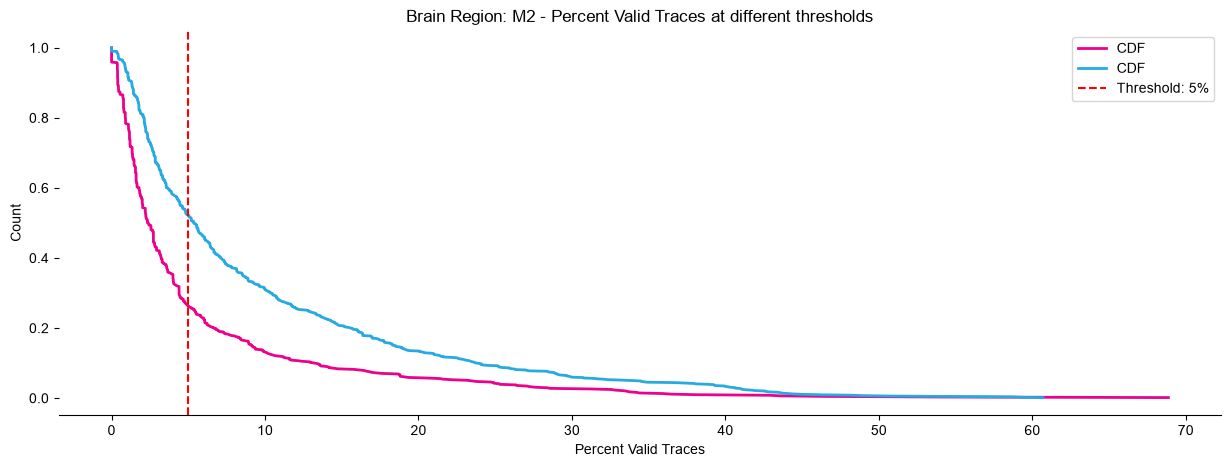

C:\Users\float\AppData\Local\Temp\ipykernel_41940\3208630291.py:131: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  prcnt_valid_sess = sub_df.groupby("ShortName").apply(
C:\Users\float\AppData\Local\Temp\ipykernel_41940\3208630291.py:131: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  prcnt_valid_sess = sub_df.groupby("ShortName").apply(
C:\Users\float\AppData\Local\Temp\ipykernel_41940\3208630291.py:131: FutureWarning

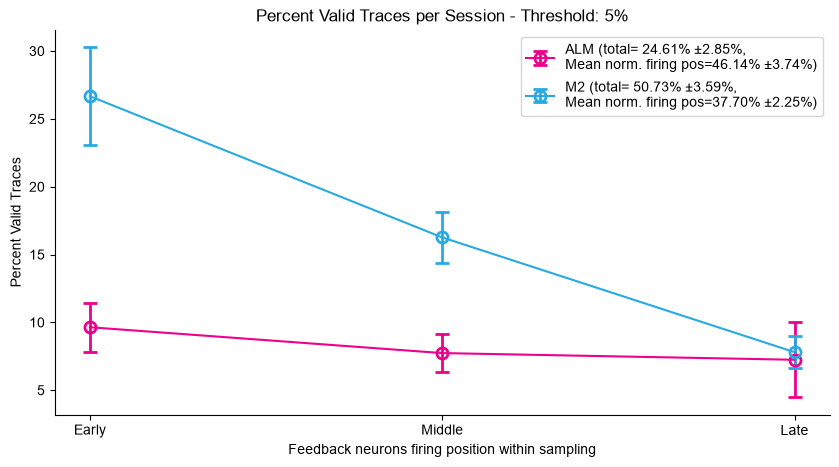

In [22]:
from .common.clr import BrainRegion as BRClr
from .pipeline.utils import filterNanGaussianConserving
import matplotlib.pyplot as plt
from scipy import stats

def plotFeedbackDist(df_feedback, df_accepted, df_stats,
                     df_accepted_normed_pos, save_figs=False):
    accepted_dict = {"BrainRegion": [], "ShortName":[], "trace_id":[], "total":[],
                     "accepted": [], "firing_pos":[]}
    idx = 0
    max_firing_pos = -1

    for br, br_df in df_feedback.groupby("BrainRegion"):    
        br_str = str(BrainRegion(br)).split("_")[0]
        for sess, sess_df in br_df.groupby("ShortName"):
            for _, row in sess_df.iterrows():
                idx += 1
                #
                long_trace_id = row.trace_id
                trace_id = int(row.trace_id.rsplit("_", 1)[1])
                long_trace_id = f"{sess}_{trace_id}"
                ref_trace = df_accepted[df_accepted.trace_id == long_trace_id]
                assert len(ref_trace) == 1, display(row) or f"Trace ID {long_trace_id} not found in reference DataFrame"
                
                ref_trace = ref_trace.iloc[0]
                #ref_accepted_traces = #np.median(ref_trace.max_vals)
                ref_threshold_std = ref_trace.std_threshold
                # ref stats
                stats_row = df_stats[df_stats.ShortName == sess].iloc[0]
                trace_stats = stats_row["neuronal_stats"][trace_id]
                trace_mean = trace_stats["mean"]
                trace_std = trace_stats["std"]
                #
                if False and (long_trace_id in examples_ids or idx % 10 == 0):
                    plot_trace = True
                    print("Trace ID:", long_trace_id)
                    fig, ax = plt.subplots()
                    fig.set_size_inches(15, 5)
                    # Accepted (green) vs rejected (grey) is judged on the trace's std against ref_threshold_std;
                    # the old amplitude threshold (ref_accepted_traces) was retired, so there is no line to draw.
                else:
                    plot_trace = False

                count_accepted = 0
                count_total = 0
                for arr in [row.whole_trace, row.invalid_whole_trace]:
                    for trace in arr:
                        trace = (trace - trace_mean) / trace_std
                        is_accepted = trace.std() >= ref_threshold_std
                        count_total += 1
                        if is_accepted:
                            count_accepted += 1
                        if plot_trace:
                            color = 'green' if is_accepted else 'gray'
                            ax.plot(np.arange(len(trace)), trace, color=color)
                
                normed_trace_row = df_accepted_normed_pos[df_accepted_normed_pos.trace_id == long_trace_id]
                assert len(normed_trace_row) == 1, display(row) or f"Trace ID {long_trace_id} not found in normed DataFrame"
                normed_trace_row = normed_trace_row.iloc[0]

                fire_pos = normed_trace_row.max_idxs.mean() if len(normed_trace_row.max_idxs) else np.nan
                if max_firing_pos == -1:
                    max_firing_pos = normed_trace_row.whole_trace.shape[-1]                

                accepted_dict["BrainRegion"].append(br_str)
                accepted_dict["ShortName"].append(sess)
                accepted_dict["trace_id"].append(trace_id)
                accepted_dict["total"].append(count_total)
                accepted_dict["accepted"].append(count_accepted)
                accepted_dict["firing_pos"].append(fire_pos)

                if plot_trace:
                    ax.set_title(f"Neuron {trace_id} - {sess}")
                    ax.set_xlabel("Time (frames)")
                    ax.set_ylabel("Normalized Activity")
                    ax.spines[["left", "right", "top"]].set_visible(False)
                    plt.show()

    print("Max firing position:", max_firing_pos)

    accepted_df = pd.DataFrame(accepted_dict)
    accepted_df["prcnt_valid"] = (accepted_df.accepted / accepted_df.total) * 100
    accepted_df["rel_firing_pos"] = accepted_df.firing_pos / max_firing_pos * 100
    accepted_df["pos"] = 0 #"Early"
    accepted_df.loc[(100/3 < accepted_df.rel_firing_pos) &
                    (accepted_df.rel_firing_pos < 100*2/3), "pos"] = 1 # "Middle"
    accepted_df.loc[100*2/3 < accepted_df.rel_firing_pos, "pos"] = 2 #"Late"
    # Assign each session the number of traces in it
    display(accepted_df)
    assert accepted_df.prcnt_valid.max() <= 100, \
        f"Percent valid {accepted_df.prcnt_valid.max()} > 100%"
    fig, ax = plt.subplots()
    fig.set_size_inches(15, 5)
    for br_str, br_df in accepted_df.groupby("BrainRegion"):
        prcnt_valid = (br_df.prcnt_valid > _PRCNT_VALID).mean() * 100
        print(f"{br_str} - @_PRCNT_VALID >=: {_PRCNT_VALID} = {prcnt_valid:.3g}%")

        # fig, ax = plt.subplots()
        # fig.set_size_inches(15, 5)
        # ax.hist(br_df.prcnt_valid, bins=np.arange(0, 102, 2), color='gray',
        #         alpha=0.5)
        prcnt_valid_sorted = br_df.prcnt_valid.sort_values()
        # print(prcnt_valid_sorted)
        # Plot CDF
        y = 1 - (prcnt_valid_sorted.reset_index(drop=True).index / len(prcnt_valid_sorted))
        # y = 100*y/len(prcnt_valid_sorted)
        x = prcnt_valid_sorted.values
        ax.plot(x, y, color=BRClr[br_str + "_Bi"],
                lw=2, label='CDF')

    ax.spines[["left", "right", "top"]].set_visible(False)
    ax.set_title(f"Brain Region: {br_str} - Percent Valid Traces at different thresholds")
    ax.set_xlabel("Percent Valid Traces")
    ax.set_ylabel("Count")
    ax.axvline(_PRCNT_VALID, ls="--", c="red", label=f"Threshold: {_PRCNT_VALID}%")
    ax.legend()
    if save_figs:
        fig.savefig(f"{RESULTS_DIR}/feedback_neurons_valid_traces_thresholds.svg",
                    bbox_inches='tight', dpi=300)
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 5))
    x_labels = ["Early", "Middle", "Late"]
    for br_str, br_df in accepted_df.groupby("BrainRegion"):
        clr = BRClr[br_str + "_Bi"]
        ys = []
        sess_counts = {sess: len(sess_df) 
                       for sess, sess_df in br_df.groupby("ShortName")}
        
        def calcDfPrcntValid(sub_df ):
            prcnt_valid_sess = sub_df.groupby("ShortName").apply(
                      lambda grp_df: 100*(grp_df.prcnt_valid > _PRCNT_VALID).sum() / 
                                     sess_counts[grp_df.ShortName.iloc[0]])
            return prcnt_valid_sess
        
        for pos in [0, 1, 2]:
            pos_df = br_df[br_df.pos == pos]
            pos_sess_mean = calcDfPrcntValid(pos_df)
            ys.append(pos_sess_mean)
            
        # print("Ys:", ys)
        ys = np.array(ys)
        ys_mean = ys.mean(axis=1)
        ys_sem = stats.sem(ys, axis=1)
        xs = [0, 1, 2]
        ys_total = calcDfPrcntValid(br_df)
        ys_total_mean = ys_total.mean()
        ys_total_sem = stats.sem(ys_total)
        max_firing_pos = br_df.groupby("ShortName").apply(
            lambda grp_df: grp_df[grp_df.prcnt_valid > _PRCNT_VALID].rel_firing_pos.mean())
        max_firing_pos_mean = max_firing_pos.mean()
        max_firing_pos_sem = stats.sem(max_firing_pos)
        ax.errorbar(xs, ys_mean, yerr=ys_sem, color=clr, 
                    marker="o", markerfacecolor='none',
                    capsize=5, elinewidth=2, markeredgewidth=2, markersize=8,
                    label=f"{br_str} (total= {ys_total_mean:.2f}% ±{ys_total_sem:.2f}%,\n"
                          f"Mean norm. firing pos={max_firing_pos_mean:.2f}% ±{max_firing_pos_sem:.2f}%)")

    ax.set_xticks(np.arange(len(x_labels)))
    ax.set_xticklabels(x_labels)
    ax.set_title(f"Percent Valid Traces per Session - Threshold: {_PRCNT_VALID}%")
    ax.set_ylabel("Percent Valid Traces")
    ax.set_xlabel("Feedback neurons firing position within sampling")
    ax.spines[["right", "top"]].set_visible(False)
    ax.legend()
    if save_figs:
        fig.savefig(f"{RESULTS_DIR}/feedback_neurons_dist_andfiring_pos.svg",
                    bbox_inches='tight', dpi=300)
    plt.show()

    return accepted_df[accepted_df.prcnt_valid > _PRCNT_VALID]


above_thresh_feedback_df = plotFeedbackDist(all_res_cut_feedback_df[all_res_cut_feedback_df.trace_id.isin(accepted_sampling_unnormed_df.trace_id)], 
                                            accepted_sampling_unnormed_df,
                                            sampling_stats_df, accepted_sampling_normed_df,
                                            save_figs=SAVE_FIGS)

In [23]:
accepted_sampling_normed_df

,trace_id,ShortName,BrainRegion,max_idxs_std,prcnt_valid,len_valid,len_all,max_idxs,max_vals,ChoiceLeft,ChoiceCorrect,active_trial_numbers,active_quantile_idx,quantile_idxs_count,whole_trace,invalid_whole_trace,std_threshold
0,GP4_23_s6_L50_D250_ALM_0,GP4_23_s6_L50_D250_ALM,6,9.319990,6.607930,15,227,"[23, 32, 5, 11, 30, 26, 5, 19, 23, 15, 23, 18,...","[2.3967276, 2.9296153, 2.904496, 6.182701, 0.9...","[0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, ...","[0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, ...","[192, 203, 214, 220, 245, 265, 270, 280, 281, ...",NaN,NaN,"[[-0.013142038, 0.14563692, 0.094753094, 0.209...","[[-0.07111809, 0.018099673, 0.093276426, 0.252...",0.490049
2,GP4_23_s6_L50_D250_ALM_2,GP4_23_s6_L50_D250_ALM,6,3.909752,13.656388,31,227,"[0, 10, 0, 1, 0, 9, 2, 0, 2, 1, 0, 0, 2, 0, 0,...","[2.827585, 3.0296266, 3.105509, 2.2850447, 4.1...","[0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, ...","[1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, ...","[181, 184, 185, 195, 198, 202, 211, 218, 219, ...",NaN,NaN,"[[2.827585, 2.641432, 2.268722, 2.080033, 1.94...","[[1.8773829, 1.4263858, 1.7722248, 2.0571895, ...",0.768324
3,GP4_23_s6_L50_D250_ALM_3,GP4_23_s6_L50_D250_ALM,6,5.088113,5.286344,12,227,"[0, 0, 2, 4, 3, 19, 2, 0, 1, 1, 0, 0]","[3.87762, 7.2368107, 8.5054, 6.048677, 3.93647...","[1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...","[0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, ...","[202, 211, 218, 221, 249, 264, 277, 279, 291, ...",NaN,NaN,"[[3.87762, 3.4710102, 2.5917692, 2.4565175, 2....","[[-0.06451154, 0.21673374, 0.8962367, 0.838507...",0.928529
4,GP4_23_s6_L50_D250_ALM_4,GP4_23_s6_L50_D250_ALM,6,11.212295,6.607930,15,227,"[16, 23, 32, 2, 26, 32, 29, 16, 2, 28, 32, 18,...","[8.354312, 2.5811055, 4.86932, 6.0964622, 2.76...","[1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, ...","[0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, ...","[167, 184, 189, 196, 210, 212, 213, 220, 246, ...",NaN,NaN,"[[3.5752814, 3.1951437, 2.788697, 2.5337505, 2...","[[-0.7784712, -0.42908818, -0.5956234, -1.0487...",0.962811
5,GP4_23_s6_L50_D250_ALM_5,GP4_23_s6_L50_D250_ALM,6,6.060679,49.339207,112,227,"[17, 19, 28, 25, 20, 19, 28, 26, 27, 26, 32, 2...","[3.961114, 1.805958, 3.6028912, 1.5410262, 2.3...","[1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, ...","[1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, ...","[168, 172, 176, 177, 178, 180, 182, 184, 188, ...",NaN,NaN,"[[1.1524688, 1.2043655, 1.2032497, 1.1891651, ...","[[-0.2580872, -0.4651814, -0.5757489, -0.55848...",0.396502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3859,GP4_85_s3_L70_D250_mm2_235,GP4_85_s3_L70_D250_mm2,15,4.393482,76.712329,168,219,"[30, 21, 30, 30, 32, 24, 30, 32, 31, 28, 22, 2...","[0.9878939, 0.1860287, 0.61310697, 0.55998933,...","[1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, ...","[1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, ...","[88, 94, 95, 98, 99, 100, 101, 103, 105, 106, ...",NaN,NaN,"[[-0.81633073, -0.8699325, -0.83617055, -0.786...","[[-0.86130303, -0.7779158, -0.7254503, -0.7321...",0.360506
3866,GP4_85_s3_L70_D250_mm2_278,GP4_85_s3_L70_D250_mm2,15,4.514917,28.767123,63,219,"[25, 22, 21, 24, 27, 17, 20, 26, 17, 19, 17, 2...","[3.3722532, 1.9602339, 2.54464, 2.6007028, 4.0...","[0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, ...","[1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, ...","[81, 85, 87, 89, 94, 97, 98, 99, 107, 110, 113...",NaN,NaN,"[[-0.17035796, -0.1580673, -0.3013857, -0.3104...","[[-0.61280334, -0.6943369, -0.6706107, -0.6427...",0.677989
3872,GP4_85_s3_L70_D250_mm2_379,GP4_85_s3_L70_D250_mm2,15,3.447361,15.068493,33,219,"[11, 12, 14, 11, 15, 7, 5, 11, 8, 16, 13, 11, ...","[3.7661507, 3.3371649, 3.7530298, 2.9027488, 1...","[0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, ...","[1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[81, 85, 87, 93, 94, 109, 113, 116, 117, 134, ...",NaN,NaN,"[[-0.026592553, 0.68028015, 1.3659292, 1.70598...","[[-0.81896555, -1.1061878, -0.84211266, -0.111...",0.827073
3873,GP4_85_s3_L70_D250_m

In [24]:
accepted_sampling_normed_df.query("trace_id == 'GP4_23_s6_L50_D250_ALM_0'").whole_trace.iloc[0].shape

(15, 33)

In [25]:
from .twop.dataload import dataPath
from .util.portablepickle import savePortable

if False:
    _FP = dataPath("above_thresh_feedback_df.pkl")
    savePortable(above_thresh_feedback_df, _FP)
    print(f"Saved above threshold feedback df to {_FP}")
above_thresh_feedback_df

,BrainRegion,ShortName,trace_id,total,accepted,firing_pos,prcnt_valid,rel_firing_pos,pos
3,ALM,GP4_23_s6_L50_D250_ALM,4,224,13,20.133333,5.803571,61.010101,1
4,ALM,GP4_23_s6_L50_D250_ALM,5,224,46,25.232143,20.535714,76.461039,2
5,ALM,GP4_23_s6_L50_D250_ALM,6,224,18,7.417582,8.035714,22.477522,0
6,ALM,GP4_23_s6_L50_D250_ALM,8,224,21,8.391304,9.375000,25.428195,0
9,ALM,GP4_23_s6_L50_D250_ALM,11,224,19,7.142857,8.482143,21.645022,0
...,...,...,...,...,...,...,...,...,...
1437,M2,GP4_85_s3_L70_D250_mm2,223,218,14,1.560000,6.422018,4.727273,0
1438,M2,GP4_85_s3_L70_D250_mm2,235,218,55,26.029762,25.229358,78.878066,2
1439,M2,GP4_85_s3_L70_D250_mm2,278,218,12,20.888889,5.504587,63.299663,1
1441,M2,GP4_85_s3_L70_D250_mm2,391,218,35,30.426667,16.055046,92.202020,2


In [26]:
def mapTrialNumbersToTraces(df, ref_df):
    ref_df = ref_df[ref_df.ChoiceLeft.notnull()]
    ref_df = ref_df.drop_duplicates(subset=["ShortName", "TrialNumber"])
    ref_df = ref_df.sort_values(["ShortName", "TrialNumber"])

    sess_trials_active_traces = {"BrainRegion":[], "ShortName": [], "TrialNumber": [], 
                                 "SamplingTime": [], "DVstr":[], "ChoiceCorrect": [], 
                                 "PrevChoiceCorrect": [],
                                 "CurrentTrialTracesCount": [], "PrevTrialTracesCount": [],
                                 "TotalTraces": []}
    for ses, sess_df in df.groupby("ShortName"):
        ref_sess_df = ref_df[ref_df.ShortName == ses]
        brain_region = ref_sess_df.BrainRegion.iloc[0]
        trial_numbers = ref_sess_df.TrialNumber.values
        sampling_times = ref_sess_df.calcStimulusTime.values
        dv_strs = ref_sess_df.DVstr.values
        choices_correct = ref_sess_df.ChoiceCorrect.values
        assert len(sess_df) == sess_df.trace_id.nunique(), \
            f"Session {ses} has duplicate trace_ids"
        total_sess_traces = len(sess_df)
        prev_trial_num = -1
        prev_trial_count = 0
        prev_choice_correct = None
        for (trial_num, sampling_time, dv_str, choice_correct) in zip(
             trial_numbers, sampling_times, dv_strs, choices_correct):
            sess_trials_active_traces["BrainRegion"].append(brain_region)
            sess_trials_active_traces["ShortName"].append(ses)
            sess_trials_active_traces["TrialNumber"].append(trial_num)
            sess_trials_active_traces["SamplingTime"].append(sampling_time)
            sess_trials_active_traces["DVstr"].append(dv_str)
            sess_trials_active_traces["ChoiceCorrect"].append(choice_correct)
            traces_count = sess_df.active_trial_numbers.apply(lambda x: trial_num in x)
            traces_count = traces_count.astype(int).sum()
            sess_trials_active_traces["CurrentTrialTracesCount"].append(traces_count)
            sess_trials_active_traces["TotalTraces"].append(total_sess_traces)
            if prev_trial_num == trial_num - 1:
                sess_trials_active_traces["PrevChoiceCorrect"].append(prev_choice_correct)
                sess_trials_active_traces["PrevTrialTracesCount"].append(prev_trial_count)
            else:
                sess_trials_active_traces["PrevChoiceCorrect"].append(np.nan)
                sess_trials_active_traces["PrevTrialTracesCount"].append(np.nan)
            prev_trial_num = trial_num
            prev_choice_correct = choice_correct
            prev_trial_count = traces_count

    return pd.DataFrame(sess_trials_active_traces)

ONLY_SAMPLING_TRACES = False
trials_active_counts_df = \
    mapTrialNumbersToTraces(all_res_cut_feedback_df if not ONLY_SAMPLING_TRACES else all_res_cut_feedback_df[all_res_cut_feedback_df.trace_id.isin(accepted_sampling_traces)],
                            ref_df=df_all_by_epoch.query("Layer in ['L23', 'L5'] and BrainRegion in [15, 6]"))
trials_active_counts_df

,BrainRegion,ShortName,TrialNumber,SamplingTime,DVstr,ChoiceCorrect,PrevChoiceCorrect,CurrentTrialTracesCount,PrevTrialTracesCount,TotalTraces
0,15,GP4_23_S1_L50_D250_mm2,42,1.1627,Easy,1.0,NaN,140,NaN,495
1,15,GP4_23_S1_L50_D250_mm2,43,0.8047,Easy,1.0,1.0,184,140.0,495
2,15,GP4_23_S1_L50_D250_mm2,44,0.8356,Easy,1.0,1.0,140,184.0,495
3,15,GP4_23_S1_L50_D250_mm2,45,0.7941,Med,0.0,1.0,143,140.0,495
4,15,GP4_23_S1_L50_D250_mm2,46,0.8260,Easy,1.0,0.0,126,143.0,495
...,...,...,...,...,...,...,...,...,...,...
5405,6,gp4_81_S8_L65_D250_ALM,407,0.8001,Easy,0.0,1.0,21,26.0,90
5406,6,gp4_81_S8_L65_D250_ALM,408,0.7885,Easy,0.0,0.0,14,21.0,90
5407,6,gp4_81_S8_L65_D250_ALM,409,0.7285,Hard,0.0,0.0,29,14.0,90
5408,6,gp4_81_S8_L65_D250_ALM,410,0.6741,Easy,1.0,0.0,26,29.0,90


In [27]:
import matplotlib.pyplot as plt
from scipy.stats import linregress
def plotRTVsActiveTraces(df):
    # df = df[df.SamplingTime <= 3]
    FIX_EASY = True
    if FIX_EASY:
        df = df[df.DVstr == "Easy"]
    # count_col = "CurrentTrialTracesCount"
    count_col = "PrevTrialTracesCount"
    x_col = "SamplingTime"
    # x_col = "PrevChoiceCorrect"
    df = df[df[x_col].notnull()]
    df = df[df[count_col].notnull()]
    br_r_values = {}
    for br, br_df in df.groupby("BrainRegion"):
        br_r_values[br] = []
        for sess, sess_df in br_df.groupby("ShortName"):
            br = BrainRegion(sess_df.BrainRegion.iloc[0])
            fig, ax = plt.subplots(figsize=(10, 5))
            ax.set_title(f"Session: {sess} - Active Traces vs RT\nY-axis: {count_col}")
            ax.set_xlabel("Reaction Time (s)")
            ax.set_ylabel("Active Traces %")
            ax.spines[["right", "top"]].set_visible(False)
            # Get IQR
            # q1 = sess_df[x_col].quantile(0.25)
            # q3 = sess_df[x_col].quantile(0.75)
            # iqr = q3 - q1
            # sess_df = sess_df[(sess_df[x_col] >= q1 - 1.5 * iqr) & (sess_df[x_col] <= q3 + 1.5 * iqr)]
            sess_df = sess_df.sort_values(x_col)
            ax.scatter(sess_df[x_col], sess_df[count_col]/sess_df.TotalTraces*100,
                    c=BRClr[br], alpha=0.5)
            # Plot a linear fit
            slope, intercept, r_value, p_value, std_err = linregress(sess_df[x_col],
                                                                    sess_df[count_col]/sess_df.TotalTraces*100)
            x_fit = np.linspace(sess_df[x_col].min(), sess_df[x_col].max(), 100)
            y_fit = slope * x_fit + intercept
            ax.plot(x_fit, y_fit, color='red', label=f"Fit: R={r_value:.2f} - R²={r_value**2:.2f} - P={p_value:.2g}")
            ax.legend()
            # ax.set_ylim(0, 100)
            # ax.set_xlim(0, 3)
            ax.legend()
            plt.close()
            plt.show()
            br_r_values[br].append(r_value)
        
    fig, ax = plt.subplots(figsize=(10, 5))
    easy_trials_str = "in Easy trials only\n" if FIX_EASY else ""
    extra_str = "For only sampling traces" if ONLY_SAMPLING_TRACES else "For all traces (including non-active sampling traces)"
    count_col_str = "Previous Trial" if count_col == "PrevTrialTracesCount" else "Current Trial"
    ax.set_title(f"Active Traces vs RT - R correlation per Brain Region\n"
                 f"{easy_trials_str}"
                 f"{extra_str}\n"
                 f"{count_col_str} Feedback active traces % vs {x_col} R-correlatin")
    for idx, (br, r_values) in enumerate(br_r_values.items()):
        br_str = str(BrainRegion(br)).split("_")[0]
        ax.scatter([br_str]*len(r_values), r_values, label=br_str,
                   color=BRClr[br_str + "_Bi"], alpha=0.5)
    ax.axhline(0, color='black', ls='--')
    ax.spines[["right", "top"]].set_visible(False)
    ax.set_ylabel("R correlation")
    ax.set_xlabel("Brain Region")
    ax.set_ylim(-.5, .5)
    ax.set_xlim(-0.5, len(br_r_values) - 0.5)
    plt.show()

plotRTVsActiveTraces(trials_active_counts_df)

In [28]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(df_all_by_epoch.query("Layer == 'L23' and BrainRegion in [6, 15]")[["BrainRegion", "ShortName", "epoch"]].value_counts()
          .sort_index())

BrainRegion  ShortName                epoch                   
6            GP4_23_s6_L50_D250_ALM   Decision Time                 1
                                      Movement to Lateral Port    228
                                      Punishment                   63
                                      Reward                      161
                                      Sampling                    231
                                      Wait Trial Start            233
             GP4_23_s7_L50_D250_ALM   Decision Time                 6
                                      Movement to Lateral Port    250
                                      Punishment                   74
                                      Reward                      176
                                      Sampling                    254
                                      Wait Trial Start            254
             GP4_23_s8_L50_D250_ALM   Decision Time                 2
                           

In [29]:
# pd.DataFrame(all_res_unnormed_dict).to_pickle("pkl/active_neurons_unnormed.pkl")

## Plot Active neurons distribution

In [30]:
from .twop.tracereliability import setupEpochAxes

from .common.clr import BrainRegion as BRClr

_MAX_X = None # Will be set to the max trace length
_BINS_STEP = 4
def plotActiveDistSgf(res_dict, isValidAndFirePost, save_fig=False):
    global _MAX_X
    df = pd.DataFrame(res_dict)
    # display(df)
    ex_trace = next(iter(normed_sampling_df.iloc[0].traces_sets["neuronal"].values()))
    # trace_len = len(ex_trace)
    # print("trace_len:", trace_len)
    res_rows = []
    print(ex_trace)
    _MAX_X = len(ex_trace)#/30
    fig, axs,  = plt.subplots(3, 1, figsize=(10, 18))
    fig2, ax_bar = plt.subplots()
    bar_x_ticks = []
    bar_x_tick_labels = []
    for br, br_df in df.groupby("BrainRegion"):
        br = BrainRegion(br)
        br_str = str(br).split("_")[0]
        br_clr = BRClr[BrainRegion(br)]
        count_all = 0
        count_valid = 0
        res_x_valid = []
        res_x_invalid = []
        res_rows_br = []
        for _, row in br_df.iterrows():
            count_all += 1
            row = row.copy()
            is_valid, fire_pos = isValidAndFirePost(row)
            row["valid"]  = is_valid
            res_rows_br.append(row)
            if not is_valid:
                res_x_invalid.append(fire_pos)
                continue
            res_x_valid.append(fire_pos)
            count_valid += 1
            # metric = row.max_vals
            # quantiles = row.quantile_idx
        res_rows += res_rows_br

        res_x_all = np.array(res_x_valid + res_x_invalid)
        assert len(res_x_all) == count_all
        res_x_valid = np.array(res_x_valid)
        assert len(res_x_valid) == count_valid
        res_x_invalid = np.array(res_x_invalid)
        # print("Res x:", res_x)
        bins = np.arange(_MAX_X + _BINS_STEP, step=_BINS_STEP)
        print("bins:", bins)
        #assert res_x_valid.max() <= max_x, f"{res_x_valid.max() = } != {max_x = }"
        for xs, ls, dscrp, count, ax in [(res_x_valid, "-", "Active", count_valid, axs[0]),
                                         (res_x_all, "--", "All", count_all, axs[1]),
                                         (res_x_invalid, ":", "Inactive", count_all-count_valid, axs[2]),
                              ]:
            hist, _ = np.histogram(xs, bins=bins)
            hist = 100*hist.astype(float)/count
            # print("hist:", hist, "- hist sum = ", hist.sum())
            ax.step(bins[:-1], hist,  color=br_clr, where="post", ls=ls,#align="edge", width=1, histtype="step")
                    label=f"{br_str} {dscrp}")
        print(f"{br_str} - All neurons: {count_all:,} - valid: {count_valid:,}"
              f"- Valid prcnt: {100*count_valid/count_all:.2f}")

        # Plot bar
        sess_grpby_len_all = br_df.groupby("ShortName").size()
        # Give it a name so we can merge it
        sess_grpby_len_all.name = "num_all_neurons"
        # display(sess_grpby_len_all)
        br_df_valid = pd.DataFrame(res_rows_br).query("valid")
        sess_grpby_len_valid = br_df_valid.groupby("ShortName").size()
        sess_grpby_len_valid.name = "num_valid_neurons"
        # merge
        sess_grpby = pd.merge(sess_grpby_len_all, sess_grpby_len_valid,
                              left_index=True, right_index=True,)
        # display(sess_grpby)
        sess_grpby["prcnt"] = (
                    100*sess_grpby.num_valid_neurons/sess_grpby.num_all_neurons)
        # display(sess_grpby[["num_active_neurons_df_f", "num_neurons", "prcnt"]])
        prcnt_mean = sess_grpby.prcnt.mean()
        USE_SEM = False
        if USE_SEM:
            prcnt_sem = sess_grpby.prcnt.sem()
            sem_str = "sem"
        else:
            prcnt_sem = sess_grpby.prcnt.std()
            sem_str = "std."
        # ax.errorbar(len(x_ticks), prcnt_mean, yerr=prcnt_sem, fmt="o", color=br_clr)
        ax_bar.bar(len(bar_x_ticks), prcnt_mean, yerr=prcnt_sem, color=br_clr)
        sum_all_neurons = sess_grpby.num_all_neurons.sum()
        sum_all_active = sess_grpby.num_valid_neurons.sum()
        bar_x_tick_labels.append(f"{br_str}\n"
                             #  f"{layer}\n"
                             f"{sum_all_active:,} active / {sum_all_neurons:,} Neurons\n"
                             f"Gloval mean: {100*sum_all_active/sum_all_neurons:.2f}\n"
                             f"Mean: {prcnt_mean:.2f}% ± {prcnt_sem:.2f} {sem_str}\n"
                             )
        bar_x_ticks.append(len(bar_x_ticks))
    ax_bar.set_xticks(bar_x_ticks)
    ax_bar.set_xticklabels(bar_x_tick_labels)
    ax_bar.set_ylabel("Accepted Neurons %")
    ax_bar.set_title("Accepted Neurons % per Brain Region")
    ax_bar.spines[["left", "right", "top"]].set_visible(False)

    for ax, ax_title in zip(axs, ["Active (Accepted)", "All", "Inactive"]):
        ax.set_title(f"{ax_title} Max. Firing Position")
        setupEpochAxes([ax], normed_sampling_df.iloc[0])
        ax.set_ylabel(f"Neurons %")
        for _ax in [ax]:
            _ax.set_xlabel("Normalized Time (s)")
        ax.set_ylim(bottom=0)
        ax.legend(loc="upper center")
    if save_fig:
        fig.savefig(f"{fig_save_prefix}/accepted_neurons_dst.svg")
        fig2.savefig(f"{fig_save_prefix}/accepted_neurons_prcnt.svg")
    plt.show()
    return pd.DataFrame(res_rows)


In [31]:
# import pickle
# with open("pkl/neurons_iqr_df_all_trials.pkl", 'rb') as f:
#     neurons_iqr_df_all_trials = pickle.load(f)

In [32]:
PRCNT_VALID = 5
def getIsValidAndFirePostUnnormed(row):
    is_valid = row.prcnt_valid >= PRCNT_VALID
    fire_pos = row.max_idxs.mean() if len(row.max_idxs) else np.nan
    return is_valid, fire_pos

is_active_unormed_df = plotActiveDistSgf(all_res_unnormed_dict, getIsValidAndFirePostUnnormed)

[-0.10978051 -1.0031167   0.1361155   2.4775758   0.4550789   0.807031
 -1.2667735  -0.90999556 -0.28771344 -0.7379092  -0.66570336 -0.47107375
 -1.1482661  -0.09649077 -1.240345   -1.5960062  -0.20068766  0.16150206
 -0.30223718  0.22527222 -0.80020267  0.95700043  0.08415095 -0.5650542
  0.29315862 -0.6777426  -0.67717814 -0.15537755 -0.10195556 -0.31920403
  0.19508372  1.909203   -1.0340394 ]


bins: [ 0  4  8 12 16 20 24 28 32 36]
ALM - All neurons: 1,536 - valid: 609- Valid prcnt: 39.65


bins: [ 0  4  8 12 16 20 24 28 32 36]
M2 - All neurons: 2,340 - valid: 837- Valid prcnt: 35.77


In [33]:

def getIsValidAndFirePostNormed(row):
    unnormed_row = is_active_unormed_df[is_active_unormed_df.trace_id == row.trace_id]
    assert len(unnormed_row) == 1, f"{len(unnormed_row)} != 1"
    is_valid = unnormed_row.valid.iloc[0]
    fire_pos = row.max_idxs.mean() if len(row.max_idxs) else np.nan #if is_valid else None
    return is_valid, fire_pos

# all_res_normed_dict = res_dict
is_active_normed_df = plotActiveDistSgf(all_res_normed_dict, getIsValidAndFirePostNormed, save_fig=False)

[-0.10978051 -1.0031167   0.1361155   2.4775758   0.4550789   0.807031
 -1.2667735  -0.90999556 -0.28771344 -0.7379092  -0.66570336 -0.47107375
 -1.1482661  -0.09649077 -1.240345   -1.5960062  -0.20068766  0.16150206
 -0.30223718  0.22527222 -0.80020267  0.95700043  0.08415095 -0.5650542
  0.29315862 -0.6777426  -0.67717814 -0.15537755 -0.10195556 -0.31920403
  0.19508372  1.909203   -1.0340394 ]


bins: [ 0  4  8 12 16 20 24 28 32 36]
ALM - All neurons: 1,536 - valid: 609- Valid prcnt: 39.65


bins: [ 0  4  8 12 16 20 24 28 32 36]
M2 - All neurons: 2,340 - valid: 837- Valid prcnt: 35.77


## Feedback neurrons distirbution

In [34]:
from .twop.tracereliability import setupEpochAxes

def plotFeedbackDistInSampling(feedback_df, sampling_df, accepted_sampling_traces,
                               isValidAndFirePost):
    display(feedback_df)
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.set_size_inches(10, 5)
    print("Max trace length:", _MAX_X)
    AS_BINS = False
    AS_SESS_MEAN = True
    if AS_BINS:
        bins = np.arange(_MAX_X + _BINS_STEP, step=_BINS_STEP)
    elif AS_SESS_MEAN:
        y_idx_offset = .5
        data = []
    for br_str, br_df in feedback_df.groupby("BrainRegion"):
        br_clr = BRClr[br_str + "_Bi"]
        if AS_BINS:
            bins_counts = []
        elif AS_SESS_MEAN:
            traces_pos_li = []
            traces_prcnt_li = []
        for sess, sess_df in br_df.groupby("ShortName"):
            traces_pos = []
            for _, row in sess_df.iterrows():
                long_traace_id = f"{sess}_{row.trace_id}"
                sampling_row = sampling_df[sampling_df.trace_id == long_traace_id]
                assert len(sampling_row) == 1, f"Trace ID {row.trace_id} not found in sampling DataFrame"
                sampling_row = sampling_row.iloc[0]
                is_valid, fire_pos = isValidAndFirePost(sampling_row)
                assert fire_pos <= _MAX_X, f"Fire position {fire_pos} > max trace length {_MAX_X}"
                assert is_valid, f"Row {row.trace_id} is not valid"
                traces_pos.append(fire_pos)
            traces_pos = np.array(traces_pos)
            if AS_BINS:
                hist, _ = np.histogram(traces_pos, bins=bins)
                if len(traces_pos) == 3:
                    print("Traces pos:", traces_pos, "bins:", bins, "- hist:", hist)
                hist = 100*hist.astype(float)/len(traces_pos)
                print(f"{br_str} - {sess} - {len(traces_pos)} traces - Mean pos: {traces_pos.mean():.2f} - ")
                bins_counts.append(hist)
            elif AS_SESS_MEAN:
                traces_pos_li.append(traces_pos)
                accepted_session_traces = accepted_sampling_traces[accepted_sampling_traces.str.startswith(sess)]
                prcnt_accepted = len(traces_pos) / len(accepted_session_traces) * 100
                traces_prcnt_li.append(prcnt_accepted)
        if AS_BINS:
            bins_counts = np.array(bins_counts)
            ax.step(bins[:-1], bins_counts.mean(axis=0), color=br_clr, where="post", ls="-",
                    label=f"{br_str} - Feedback Traces")
        elif AS_SESS_MEAN:
            print("BR clr:", br_clr, "Traces pos len:", len(traces_pos_li))
            # for idx, traces_pos in enumerate(traces_pos_li):
            #     ax.scatter(traces_pos, [y_idx_offset + idx]*len(traces_pos), color=br_clr)
            # y_idx_offset += len(traces_pos_li)
            # for traces_pos, prcnt_accepted in zip(traces_pos_li, traces_prcnt_li):
            #     mean_traces_pos = np.mean(traces_pos)
            #     print(f"{br_str} - Mean pos: {mean_traces_pos:.2f} - Accepted: {prcnt_accepted:.2f}%")
            #     ax.scatter(mean_traces_pos, prcnt_accepted, color=br_clr)
            #
            # traces_means = [np.mean(traces_pos) for traces_pos in traces_pos_li]
            # ax.boxplot(traces_means, 
            #            positions=[y_idx_offset], 
            #            widths=0.5,
            #            #orientation='horizontal',
            #            vert=False,
            #            patch_artist=True, showfliers=True,
            #            boxprops=dict(facecolor=br_clr, color=br_clr),
            #            medianprops=dict(color='k'),
            #            whiskerprops=dict(color=br_clr),
            #            capprops=dict(color=br_clr),
            #            flierprops=dict(markerfacecolor=br_clr, marker='o', markersize=5)
            #            )
            # y_idx_offset += 1
            #
            concate_pos = np.concatenate(traces_pos_li)
            # concate_pos = np.sort(concate_pos)
            # print("Concatenated traces pos len:", concate_pos)
            data.append((br_str, concate_pos, br_clr))
            # parts = ax.violinplot(concate_pos,
            #                       positions=[y_idx_offset],
            #                       #showmeans=True, showmedians=True,
            #                       points=20,
            #                     #   bw_method="silverman",
            #                       bw_method=0.3,
            #                       vert=False,
            #                       showextrema=True,
            #                      )
            # for pc in parts['bodies']:
            #     pc.set_facecolor(br_clr)
            #     pc.set_edgecolor(br_clr)
            #     pc.set_alpha(0.5)
            # for idx, pos in enumerate(concate_pos):
            #     offset = (y_idx_offset - 0.25) + (idx % 10) * 0.05
            #     # print(f"Scatter pos: {pos} - offset: {offset} - idx: {idx}")
            #     ax.scatter(pos, offset, color=br_clr, alpha=1)
            # y_idx_offset += 1
    if AS_SESS_MEAN:
        import seaborn as sns
        parts = sns.violinplot(data=[d[1] for d in data],
                            #   positions=[y_idx_offset + i for i in range(len(data))],
                              width=0.5,
                              #showmeans=True, showmedians=True,
                                # points=20,
                                # bw_method=0.3,
                                order=[1, 0],
                                palette={idx: d[2] for idx, d in enumerate(data)},
                                orient='h',
                                ax=ax,
                                common_norm=True,
                                hue_norm=True,
                                inner=None,
                              )
        sns.stripplot(data=[d[1] for d in data],
                      #   positions=[y_idx_offset + i for i in range(len(data))],
                        jitter=.2,
                        size=3,
                        # alpha=0.5,
                        ax=ax,
                        order=[1, 0],
                        palette={idx: 'k' for idx, d in enumerate(data)},
                        orient='h',
                        hue_norm=True,
                        )
        # data_df = pd.DataFrame(data, columns=["BrainRegion", "traces_pos", "color"])
        # data_df["y_pos"] = np.arange(len(data_df)) + 0.5
        # Expand data to non-array format for seaborn
        # data = [(d[0], pos, d[2], 1 if d[0] == "ALM" else 0)
        #         for d in data for pos in d[1]]
        # # print("Data:", data)
        # data_df = pd.DataFrame(data, columns=["BrainRegion", "traces_pos", "color", "y_pos"])

        # # print("Data DF:", data_df)
        # #
        # print("Data DF:", data_df.dtypes)
        # # data_df.set_index("BrainRegion", inplace=True)
        # display(data_df)
        # sns.stripplot(data=data_df,#[data_df.BrainRegion == "M2"],
        #               x="traces_pos",
        #               y="y_pos",
        #               hue="BrainRegion",
        #               native_scale=True,
        #               jitter=2,
        #               dodge=True,
        #                 size=3,
        #                 # alpha=0.5,
        #                 ax=ax,
        #             #  palette=data_df["color"],
        #                 # orient='h',
        #                 # hue_norm=True,
        #                 )
        # sns.stripplot(data=data_df[data_df.BrainRegion == "ALM"],
        #                 x="traces_pos",
        #                 y="y_pos",
        #                 jitter=.2,
        #                 size=3,
        #                 # alpha=0.5,
        #                 ax=ax,
        #                 # palette={idx: 'k' for idx, d in enumerate(data)},
        #                 orient='h',
        #                 hue_norm=True,
        #                 )

    setupEpochAxes([ax], normed_sampling_df.iloc[0])    
    ax.set_xlabel("Normalized Time (s)")
    # ax.set_ylim(bottom=0)
    ax.set_title("Feedback Traces Mean Peak Firing Position in Sampling Traces")
    if AS_BINS:
        ax.set_ylabel("Neurons %")
        ax.legend(loc="upper center")
    elif AS_SESS_MEAN:
        ax.set_yticks([])
        ax.set_ylim(1.5, -.5)

plotFeedbackDistInSampling(above_thresh_feedback_df,
                           all_res_normed_df,
                           accepted_sampling_traces,
                           getIsValidAndFirePostNormed)

,BrainRegion,ShortName,trace_id,total,accepted,firing_pos,prcnt_valid,rel_firing_pos,pos
3,ALM,GP4_23_s6_L50_D250_ALM,4,224,13,20.133333,5.803571,61.010101,1
4,ALM,GP4_23_s6_L50_D250_ALM,5,224,46,25.232143,20.535714,76.461039,2
5,ALM,GP4_23_s6_L50_D250_ALM,6,224,18,7.417582,8.035714,22.477522,0
6,ALM,GP4_23_s6_L50_D250_ALM,8,224,21,8.391304,9.375000,25.428195,0
9,ALM,GP4_23_s6_L50_D250_ALM,11,224,19,7.142857,8.482143,21.645022,0
...,...,...,...,...,...,...,...,...,...
1437,M2,GP4_85_s3_L70_D250_mm2,223,218,14,1.560000,6.422018,4.727273,0
1438,M2,GP4_85_s3_L70_D250_mm2,235,218,55,26.029762,25.229358,78.878066,2
1439,M2,GP4_85_s3_L70_D250_mm2,278,218,12,20.888889,5.504587,63.299663,1
1441,M2,GP4_85_s3_L70_D250_mm2,391,218,35,30.426667,16.055046,92.202020,2


Max trace length: 33
BR clr: #EC008C Traces pos len: 10


BR clr: #27AAE1 Traces pos len: 13


## Feedback correlation with next trial

In [35]:
from tqdm.auto import tqdm
def prepeareDF(df_feedback, df_sampling, accepted_sampling_unnormed_df):
    df_feedback = df_feedback.copy()
    df_feedback.loc[df_feedback.epoch.isin(["Reward", "Punishment"]), "epoch"] = "Feedback"
    df_feedback["NextTrialNumber"] = (df_feedback["TrialNumber"] + 1).astype(int)

    res_dict = {"BrainRegion": [], "ShortName": [], "TrialNumber": [], 
                "trace_id": [], "long_trace_id": [],
                "FiringPos":[], "FiringPosRel": [],
                "FeedbackTrace":[], "FeedbackTraceMax": [],
                "NextSamplingTrace": [], "NextSampleTraceMax": [],}
    
    df_feedback["NextTrialNumber"] = df_feedback["TrialNumber"] + 1
    # display(df_feedback[["BrainRegion", "ShortName", "TrialNumber", "NextTrialNumber", "epoch"]].head(10))
    # display(df_sampling[["ShortName", "TrialNumber", "epoch"]].head(10))
    common_cols = ["ShortName", "TrialNumber", "traces_sets", "trace_start_idx", "trace_end_idx"]
    df_merged = pd.merge(df_feedback[["BrainRegion", "NextTrialNumber"] + common_cols], 
                         df_sampling[common_cols],
                         left_on=["ShortName", "NextTrialNumber"],
                         right_on=["ShortName", "TrialNumber"],
                         suffixes=("", "_sampling"),
                         how="left")
    df_merged = df_merged[df_merged.TrialNumber_sampling.notnull()]
    df_merged["trace_start_idx_sampling"] = df_merged["trace_start_idx_sampling"].astype(int)
    df_merged["trace_end_idx_sampling"] = df_merged["trace_end_idx_sampling"].astype(int)

    for (br, sess), sess_df in tqdm(df_merged.groupby(["BrainRegion", "ShortName"]),
                                    desc="Preparing Feedback Traces DataFrame",):
        br_str = str(BrainRegion(br)).split("_")[0]
        sess_accepted_sampling = set(accepted_sampling_unnormed_df[
            accepted_sampling_unnormed_df.ShortName == sess].trace_id.values)
        for _, row in sess_df.iterrows():
            cur_traces_sets = row.traces_sets["neuronal"]
            cur_start_idx = row.trace_start_idx
            cur_end_idx = row.trace_end_idx
            next_traces_sets = row.traces_sets_sampling["neuronal"]
            next_start_idx = row.trace_start_idx_sampling
            next_end_idx = row.trace_end_idx_sampling
            for trace_id, trace in cur_traces_sets.items():
                long_trace_id = f"{sess}_{trace_id}"
                if long_trace_id not in sess_accepted_sampling:
                    continue
                
                cur_trace = trace[cur_start_idx:cur_end_idx+1]
                next_trace = next_traces_sets[trace_id][next_start_idx:next_end_idx+1]
                max_firing_pos = np.argmax(next_trace)
                next_trace_max = next_trace[max_firing_pos]
                res_dict["BrainRegion"].append(br_str)
                res_dict["ShortName"].append(sess)
                res_dict["TrialNumber"].append(row.TrialNumber)
                res_dict["trace_id"].append(trace_id)
                res_dict["long_trace_id"].append(long_trace_id)
                res_dict["FeedbackTrace"].append(cur_trace.copy())
                res_dict["FeedbackTraceMax"].append(cur_trace.max())
                res_dict["NextSamplingTrace"].append(next_trace.copy())
                res_dict["NextSampleTraceMax"].append(next_trace_max)
                res_dict["FiringPos"].append(max_firing_pos)
                res_dict["FiringPosRel"].append(100*max_firing_pos / len(next_trace))

    # for br, br_df in tqdm(df_feedback.groupby("BrainRegion")):
    #     br_str = str(BrainRegion(br)).split("_")[0]
    #     for sess, sess_df in br_df.groupby("ShortName"):
    #         sess_sampling_df = df_sampling[df_sampling.ShortName == sess]
    #         sess_df = sess_df.copy()
            # sess_df["RollTrialNumber"] = sess_df["TrialNumber"].shift(-1)
            # sess_df["RollTracesSets"] = sess_df["traces_sets"].shift(-1)
            # sess_df["RollEpoch"] = sess_df["epoch"].shift(-1)
            # sess_df["RollTraceStartIdx"] = sess_df["trace_start_idx"].shift(-1)
            # sess_df["RollTraceEndIdx"] = sess_df["trace_end_idx"].shift(-1)
            # len_before = len(sess_df[sess_df.epoch == "Feedback"])
            # sess_df = sess_df[sess_df.RollTrialNumber == sess_df.TrialNumber + 1]
            # sess_df = sess_df[sess_df.epoch == "Feedback"]
            # sess_df = sess_df[sess_df.RollEpoch == "Sampling"]
            # sess_df["RollTraceStartIdx"] = sess_df["RollTraceStartIdx"].astype(int)
            # sess_df["RollTraceEndIdx"] = sess_df["RollTraceEndIdx"].astype(int)
            # len_after = len(sess_df)
            # print(f"Brain Region {br_str} - Session {sess} - "
            #       f"Traces before: {len_before:,} - after: {len_after:,}")
            # sess_accepted_sampling = set(accepted_sampling_unnormed_df[
            #     accepted_sampling_unnormed_df.ShortName == sess].trace_id.values)
            # # print("Sess accepted sampling traces:", sess_accepted_sampling[:2])
            # # print(f"Accepted Sampling Traces for {sess}: {len(sess_accepted_sampling)}")
            # for _, row in sess_df.iterrows():
            #     cur_traces_sets = row.traces_sets["neuronal"]
            #     cur_start_idx = row.trace_start_idx
            #     cur_end_idx = row.trace_end_idx
            #     next_traces_sets = row.RollTracesSets["neuronal"]
            #     next_start_idx = row.RollTraceStartIdx
            #     next_end_idx = row.RollTraceEndIdx
            #     for trace_id, trace in cur_traces_sets.items():
            #         long_trace_id = f"{sess}_{trace_id}"
            #         if long_trace_id not in sess_accepted_sampling:
            #             continue
            #         firing_pos_row = firing_pos_df[firing_pos_df.trace_id == long_trace_id]
            #         firing_pos = firing_pos_row.max_idxs.mean() if len(firing_pos_row) else np.nan
            #         cur_trace = trace[cur_start_idx:cur_end_idx+1]
            #         # print("next_start_idx:", next_start_idx,
            #         #       "next_end_idx:", next_end_idx,)
            #         next_trace = next_traces_sets[trace_id][next_start_idx:next_end_idx+1]
            #         res_dict["BrainRegion"].append(br_str)
            #         res_dict["ShortName"].append(sess)
            #         res_dict["TrialNumber"].append(row.TrialNumber)
            #         res_dict["trace_id"].append(trace_id)
            #         res_dict["long_trace_id"].append(long_trace_id)
            #         res_dict["FeedbackTrace"].append(cur_trace.copy())
            #         res_dict["FeedbackTraceMax"].append(cur_trace.max())
            #         res_dict["NextSamplingTrace"].append(next_trace.copy())
            #         res_dict["NextSampleTraceMax"].append(next_trace.max())
            #         res_dict["FiringPos"].append(firing_pos)
            #         res_dict["FiringPosRel"].append(firing_pos / len(next_trace)) # See assert outside forloop
    
    res_df = pd.DataFrame(res_dict)
    assert res_df["NextSamplingTrace"].apply(len).nunique() == 1, \
                    f"NextSamplingTrace lengths are not equal - {res_df['NextSamplingTrace'].apply(len).unique()}"
    return res_df

cur_feedback_next_sampling_df = prepeareDF(normed_all_df[normed_all_df.epoch.isin(["Reward", "Punishment"])], # Sampling is broken here?, 
                                           normed_sampling_df,
                                           accepted_sampling_unnormed_df)
cur_feedback_next_sampling_df

Preparing Feedback Traces DataFrame:   0%|          | 0/23 [00:00<?, ?it/s]

,BrainRegion,ShortName,TrialNumber,trace_id,long_trace_id,FiringPos,FiringPosRel,FeedbackTrace,FeedbackTraceMax,NextSamplingTrace,NextSampleTraceMax
0,ALM,GP4_23_s6_L50_D250_ALM,167,0,GP4_23_s6_L50_D250_ALM_0,11,33.333333,"[471.9137, 537.2516, 873.4656, 922.5907, 534.9...",922.590698,"[-0.06780355, -0.08496408, -0.10216399, -0.508...",1.595292
1,ALM,GP4_23_s6_L50_D250_ALM,167,2,GP4_23_s6_L50_D250_ALM_2,11,33.333333,"[882.922, 420.35327, 364.50098, 393.72058, 889...",889.535889,"[-1.0526334, -0.12448963, -0.28732786, -0.8583...",0.593372
2,ALM,GP4_23_s6_L50_D250_ALM,167,3,GP4_23_s6_L50_D250_ALM_3,6,18.181818,"[902.4972, 898.6144, 629.1488, 243.89331, 383....",902.497192,"[-0.28690386, -0.32879943, 1.6126953, 0.311361...",1.957472
3,ALM,GP4_23_s6_L50_D250_ALM,167,4,GP4_23_s6_L50_D250_ALM_4,14,42.424242,"[3533.1013, 2893.642, 2753.7178, 3010.627, 302...",3533.101318,"[-1.0699577, -0.01596374, -0.38936627, -1.1101...",1.593667
4,ALM,GP4_23_s6_L50_D250_ALM,167,5,GP4_23_s6_L50_D250_ALM_5,17,51.515152,"[1784.0723, 1631.2278, 1367.0459, 1578.7317, 1...",1855.085938,"[1.1054333, 1.2955873, 1.1066569, 1.3214297, 1...",4.431708
...,...,...,...,...,...,...,...,...,...,...,...
335283,M2,GP4_85_s3_L70_D250_mm2,307,235,GP4_85_s3_L70_D250_mm2_235,27,81.818182,"[2295.7168, 2728.4297, 2583.1245, 1319.2695, 1...",2728.429688,"[-0.7946559, -1.0668049, -1.1477958, -0.826919...",-0.095887
335284,M2,GP4_85_s3_L70_D250_mm2,307,278,GP4_85_s3_L70_D250_mm2_278,26,78.787879,"[811.03284, 835.8458, 990.0447, 771.77954, 702...",1125.754150,"[-1.0080239, -0.6593396, -1.4379921, 0.2678157...",0.362458
335285,M2,GP4_85_s3_L70_D250_mm2,307,379,GP4_85_s3_L70_D250_mm2_379,24,72.727273,"[446.54993, 423.68933, 424.31555, 330.7284, 28...",623.608887,"[-1.0647919, -1.9616328, -0.10932224, -1.36762...",0.426794
335286,M2,GP4_85_s3_L70_D250_mm2,307,391,GP4_85_s3_L70_D250_mm2_391,28,84.848485,"[2881.744, 2266.0664, 2122.1016, 2782.1064, 25...",2881.743896,"[-0.5463443, -0.58647996, -0.44215962, -0.5246...",2.163683


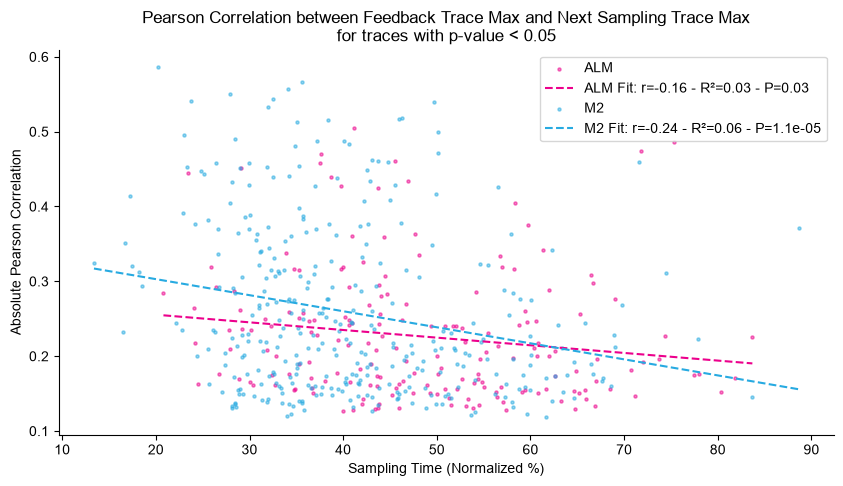

In [36]:
from .common.clr import BrainRegion as BRClr
import matplotlib.pyplot as plt
from scipy import stats

def corrNextTrial(df, save_figs=False):
    res_dict = {"BrainRegion": [], "ShortName": [], "TraceID":[], "MeanFiringPos": [],
                "corr": [], "pval": []}
    for br, br_df in df.groupby("BrainRegion"):
        for sess, sess_df in br_df.groupby("ShortName"):
            for trace_id, trace_df in sess_df.groupby("trace_id"):
                if len(trace_df) < 2:
                    continue
                # print("Trace ID:", trace_id, " - len:", len(trace_df))
                x = trace_df.FeedbackTraceMax.values
                y = trace_df.NextSampleTraceMax.values
                corr, pval = stats.pearsonr(x, y)
                mean_firing_pos = trace_df.FiringPosRel.mean()
                res_dict["BrainRegion"].append(br)
                res_dict["ShortName"].append(sess)
                res_dict["TraceID"].append(trace_id)
                res_dict["MeanFiringPos"].append(mean_firing_pos)
                res_dict["corr"].append(corr)
                res_dict["pval"].append(pval)

    res_df = pd.DataFrame(res_dict)

    fig, ax = plt.subplots(figsize=(10, 5))
    for br, br_df in res_df.groupby("BrainRegion"):
        br_clr = BRClr[br + "_Bi"]
        # STEP_PRCNT = 10
        # bins = np.arange(0, 100 + STEP_PRCNT, step=STEP_PRCNT)
        br_df = br_df.sort_values("MeanFiringPos")
        br_df = br_df[br_df.pval < 0.05]  # Filter by p-value
        br_df = br_df.copy()
        br_df["corrAbs"] = br_df["corr"].abs()
        COL = "corrAbs"
        ax.scatter(br_df.MeanFiringPos.values, br_df[COL].values, label=br, 
                   color=br_clr, alpha=0.5, s=5)
        # Fit a line
        slope, intercept, r_value, p_value, std_err = stats.linregress(
                                 br_df.MeanFiringPos.values, br_df[COL].values)
        x_fit = np.linspace(br_df.MeanFiringPos.min(), br_df.MeanFiringPos.max(), 100)
        y_fit = slope * x_fit + intercept
        ax.plot(x_fit, y_fit, color=br_clr, ls='--', label=f"{br} Fit: r={r_value:.2f} - R²={r_value**2:.2f} - P={p_value:.2g}")
                   
    ax.set_xlabel("Sampling Time (Normalized %)")
    ax.set_title("Pearson Correlation between Feedback Trace Max and Next Sampling Trace Max\n"
                 "for traces with p-value < 0.05")
    ax.set_ylabel("Absolute Pearson Correlation")
    ax.spines[["right", "top"]].set_visible(False)
    ax.legend()
    if save_figs:
        fig.savefig(f"{RESULTS_DIR}/corr_feedback_next_sampling.svg")
    plt.show()

corrNextTrial(cur_feedback_next_sampling_df, save_figs=SAVE_FIGS)

## Loop Example Neurons

In [37]:
is_active_unormed_df.groupby(["BrainRegion", "ShortName"]).agg(
    {"valid":"sum", "trace_id":"count"}
)

valid  trace_id
BrainRegion ShortName                               
6           GP4_23_s6_L50_D250_ALM      77       177
            GP4_23_s7_L50_D250_ALM     106       265
            GP4_23_s8_L50_D250_ALM      94       253
            GP4_85_s10_L70_D250_ALM     38       112
            GP4_85_s6_L65_D250_ALM      60       144
            GP4_85_s7_L70_D250_ALM      69       190
            GP4_85_s8_L60_D250_ALM      19        75
            GP4_85_s9_L70_D250_ALM      62       151
            gp4_81_S5_L50_D250_ALM      42        79
            gp4_81_S8_L65_D250_ALM      42        90
15          GP4_23_S1_L50_D250_mm2     165       495
            GP4_23_s3_L50_D250_M2      122       313
            GP4_24_s4_L85_D250_M2       32       119
            GP4_28_S1_L41_D250_M2L      44       133
            GP4_28_S2_L51_D250_M2L      63       176
            GP4_28_S4_L40_D250_M2L      43       108
            GP4_28_S5_L40_D250_M2L      56       116
            GP4_28_S6_L40_D250_M2L      38       107
            GP4_80_S2_L51_D250_M2m      54       188
            GP4_80_S4_L50_D250_M2m      45       176
            GP4_85_S1_L70_D250_mm2      50       124
            GP4_85_s2_L100_D250_mm2     50       116
            GP4_85_s3_L70_D250_mm2      75       169

# Continue here with neurons filtering and df/f calculation

In [38]:
from .pipeline import pipeline, tracesnormalize, tracesmath

def calcDF_F(df, copy_data):
  # df = df[df.anlys_path == df.anlys_path.iloc[0]]
  sampling_rates = df.acq_sampling_rate.unique()
  assert len(sampling_rates) == 1
  assert int(sampling_rates[0]) == 30
  display(df.sole_owner.unique())
  chain = pipeline.Chain(
    pipeline.BySession(),
      pipeline.ApplyFullTrace(
              # TODO Add the sigma as function of sampling rate. Current
              # Sampling rate is 30
              tracesmath.GaussianFilter(sigma=1, copy_data=copy_data),
              tracesnormalize.CalcBaseline(track_is_active=False)),
    pipeline.RecombineResults(),
  )
  return chain.run(df)

df_all_by_epoch_df_f = calcDF_F(df_all_by_epoch.copy(), copy_data=True)

array([False])

Processing: Split data by trial ['Name', 'Date', 'SessionNum']
Processing: Applying on full trace


  0%|          | 0/23 [00:00<?, ?it/s]

Processing: Smoothing traces with gaussian filter with sigma: 1


Processing: Calculating baseline
Processing GP4_23_S1_L50_D250_mm2 - ('GP4-23', datetime.date(2022, 6, 26), 2)


...

Processing: Smoothing traces with gaussian filter with sigma: 1
Processing: Calculating baseline
Processing GP4_85_s7_L70_D250_ALM - ('GP4-85', datetime.date(2022, 7, 1), 1)


Processing: Smoothing traces with gaussian filter with sigma: 1
Processing: Calculating baseline
Processing GP4_85_s8_L60_D250_ALM - ('GP4-85', datetime.date(2022, 7, 3), 2)


Processing: Smoothing traces with gaussian filter with sigma: 1
Processing: Calculating baseline
Processing GP4_85_s9_L70_D250_ALM - ('GP4-85', datetime.date(2022, 7, 4), 1)


Processing: Smoothing traces with gaussian filter with sigma: 1
Processing: Calculating baseline
Processing GP4_85_s10_L70_D250_ALM - ('GP4-85', datetime.date(2022, 7, 5), 1)


Processing: Collapsing the dataframes back into one dataframe


In [39]:
def keepOnlyValidTraces(df, valid_long_traces_ids_set):
    valid_traces_by_sess = {} # Optimization that wasn't actually the bottleeneck (was bug)
    for long_trace_id in valid_long_traces_ids_set:
        sess_short_name, trace_id = long_trace_id.rsplit("_", 1)
        trace_id = int(trace_id)
        if sess_short_name not in valid_traces_by_sess:
            valid_traces_by_sess[sess_short_name] = set()
        valid_traces_by_sess[sess_short_name].add(trace_id)
    res_rows = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        short_name = row.ShortName
        sess_valid_traces = valid_traces_by_sess.get(short_name)
        if sess_valid_traces is None: # Skip unprocessed brain-regions and layers
            continue
        new_traces_sets = {}
        for set_name, trace_dict in row.traces_sets.items():
            new_traces_dict = {trace_id:trace
                               for trace_id, trace in trace_dict.items()
                               if trace_id in sess_valid_traces}
            new_traces_sets[set_name] = new_traces_dict

        row = pipeline.updateRowTracesSet(row.copy(), new_traces_sets)
        res_rows.append(row)

    return pd.DataFrame(res_rows)

df_all_by_epoch_df_f_filtered = keepOnlyValidTraces(df_all_by_epoch_df_f,
                                                    set(is_active_unormed_df[is_active_unormed_df.valid].trace_id))

  0%|          | 0/22483 [00:00<?, ?it/s]

In [40]:
from .twop.dataload import dataPath
from .util.portablepickle import savePortable

# Overwrites a file already under data/ (and in the download archive).
# savePortable refuses rather than writing one only this checkout can read.
if SAVE_DATA:
    _FP = dataPath("df_all_by_epoch_df_f_filtered.pkl")
    savePortable(df_all_by_epoch_df_f_filtered, _FP)
